In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from IPython.display import display
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
from load_ncmapss import load_ncmapss

filename = '/Users/a1/Desktop/project/pytorch_practice/data/N-CMAPSS_DS03-012.h5'

# Load the dataset
data = load_ncmapss(filename)

# 꺼내서 쓸 때
W_dev   = data['W_dev']
X_s_dev = data['X_s_dev']
X_v_dev = data['X_v_dev']
T_dev   = data['T_dev']
Y_dev   = data['Y_dev']
A_dev   = data['A_dev']

W_test   = data['W_test']
X_s_test = data['X_s_test']
X_v_test = data['X_v_test']
T_test   = data['T_test']
Y_test   = data['Y_test']
A_test   = data['A_test']

W_var   = data['W_var']
X_s_var = data['X_s_var']
X_v_var = data['X_v_var']
T_var   = data['T_var']
A_var   = data['A_var']

W shape: (9822837, 4)
X_s shape: (9822837, 14)
X_v shape: (9822837, 14)
T shape: (9822837, 10)
A shape: (9822837, 4)


In [3]:
from preprocess_ncmapss import preprocess_ncmapss

# data preprocessing
result = preprocess_ncmapss(A_dev, A_test)

normal_ranges        = result['normal_ranges']
abnormal_ranges      = result['abnormal_ranges']
test_abnormal_ranges = result['test_abnormal_ranges']
eng_dev              = result['eng_dev']
state_dev            = result['state_dev']
eng_test             = result['eng_test']
state_test           = result['state_test']
dev_all_ranges  = result['dev_all_ranges']   # 추가
test_all_ranges = result['test_all_ranges']  # 추가


=== Normal Range summary (A_dev index) ===
Total normal ranges : 9
  Engine 1 : [0, 156352] (len=156353)
  Engine 2 : [308489, 526119] (len=217631)
  Engine 3 : [955653, 1167122] (len=211470)
  Engine 4 : [1545490, 1752373] (len=206884)
  Engine 5 : [2084577, 2236339] (len=151763)
  Engine 6 : [2485720, 2754276] (len=268557)
  Engine 7 : [3432229, 3656713] (len=224485)
  Engine 8 : [4132089, 4383309] (len=251221)
  Engine 9 : [5207095, 5368001] (len=160907)

=== Abnormal Range summary (A_dev index) ===
Total abnormal ranges : 9
  Engine 1 : [156353, 308488] (len=152136)
  Engine 2 : [526120, 955652] (len=429533)
  Engine 3 : [1167123, 1545489] (len=378367)
  Engine 4 : [1752374, 2084576] (len=332203)
  Engine 5 : [2236340, 2485719] (len=249380)
  Engine 6 : [2754277, 3432228] (len=677952)
  Engine 7 : [3656714, 4132088] (len=475375)
  Engine 8 : [4383310, 5207094] (len=823785)
  Engine 9 : [5368002, 5571276] (len=203275)

=== DEV All Range summary (A_dev index) ===
Total dev ranges : 

In [4]:
from sampling_ncmapss import run_sampling

# abnormal range sampling
# result = run_sampling(
#     A_dev, A_test, eng_dev,
#     normal_ranges, abnormal_ranges, test_abnormal_ranges,
#     K=20, N=10
# )

# all range sampling
result = run_sampling(
    A_dev, A_test, eng_dev,
    normal_ranges, dev_all_ranges, test_all_ranges,
    K=20, N=10
)

dev_normal_idx      = result['dev_normal_idx']
dev_count_by_engine = result['dev_count_by_engine']
dev_abnormal_idx    = result['dev_abnormal_idx']
test_abnormal_idx   = result['test_abnormal_idx']

from tensor_prep import prepare_tensors

tensors = prepare_tensors(
    dev_normal_idx, dev_abnormal_idx, test_abnormal_idx,
    W_dev, X_s_dev, W_test, X_s_test
)

device = tensors['device']

x_dev_mean = tensors['x_dev_mean']
x_dev_std  = tensors['x_dev_std']
y_dev_mean = tensors['y_dev_mean']
y_dev_std  = tensors['y_dev_std']

x_dev_normal_scaled   = tensors['x_dev_normal_scaled']
y_dev_normal_scaled   = tensors['y_dev_normal_scaled']
x_dev_abnormal_scaled = tensors['x_dev_abnormal_scaled']
y_dev_abnormal_scaled = tensors['y_dev_abnormal_scaled']
x_test_abnormal_scaled = tensors['x_test_abnormal_scaled']
y_test_abnormal_scaled = tensors['y_test_abnormal_scaled']


=== DEV sampling (normal state, from A_dev) ===
Target engines : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Samples per range (K) : 20
  Engine 1 | range [0,156352] | range_len=156353 | sampled=20
  Engine 2 | range [308489,526119] | range_len=217631 | sampled=20
  Engine 3 | range [955653,1167122] | range_len=211470 | sampled=20
  Engine 4 | range [1545490,1752373] | range_len=206884 | sampled=20
  Engine 5 | range [2084577,2236339] | range_len=151763 | sampled=20
  Engine 6 | range [2485720,2754276] | range_len=268557 | sampled=20
  Engine 7 | range [3432229,3656713] | range_len=224485 | sampled=20
  Engine 8 | range [4132089,4383309] | range_len=251221 | sampled=20
  Engine 9 | range [5207095,5368001] | range_len=160907 | sampled=20

DEV sampled count by engine:
  Engine 1 : 20
  Engine 2 : 20
  Engine 3 : 20
  Engine 4 : 20
  Engine 5 : 20
  Engine 6 : 20
  Engine 7 : 20
  Engine 8 : 20
  Engine 9 : 20

Tot

Iter 10/100 - Loss: 0.848
Iter 20/100 - Loss: 0.356
Iter 30/100 - Loss: -0.155
Iter 40/100 - Loss: -0.664
Iter 50/100 - Loss: -1.159
Iter 60/100 - Loss: -1.633
Iter 70/100 - Loss: -2.062
Iter 80/100 - Loss: -2.406
Iter 90/100 - Loss: -2.639
Iter 100/100 - Loss: -2.769


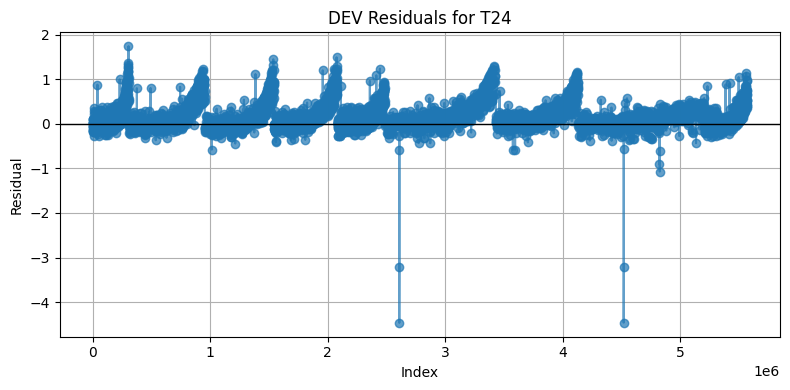

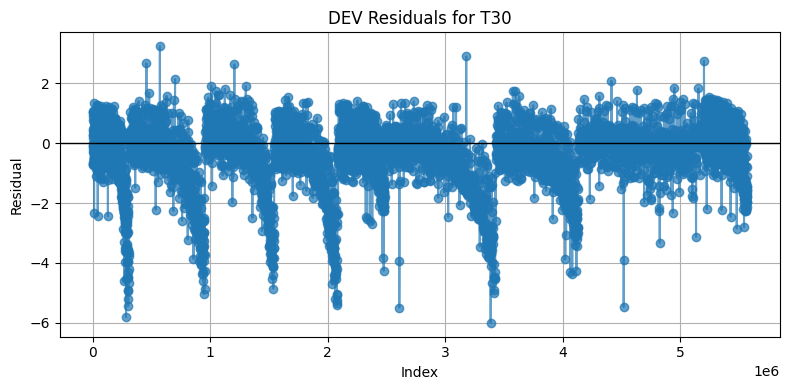

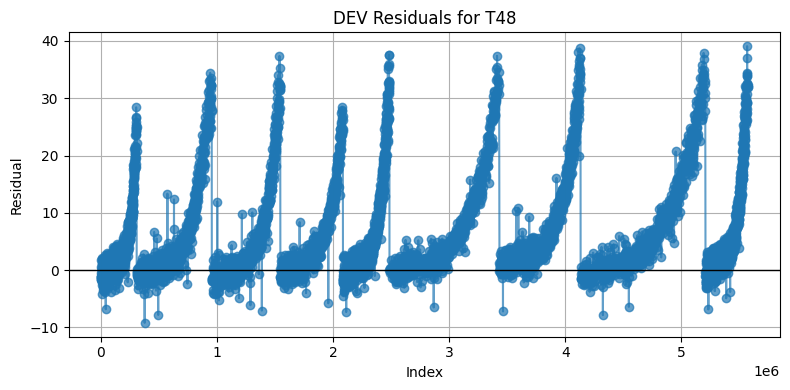

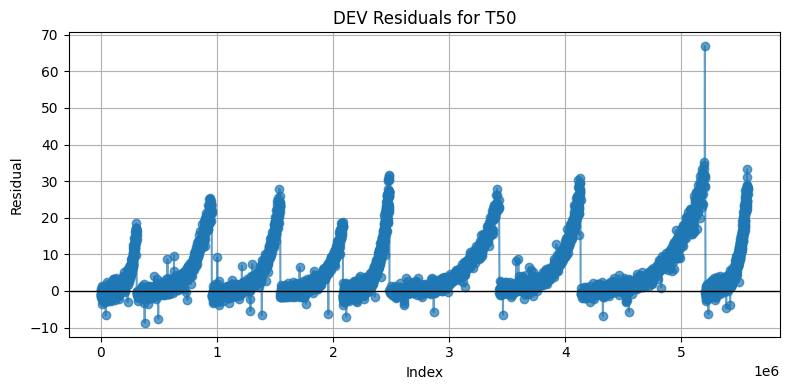

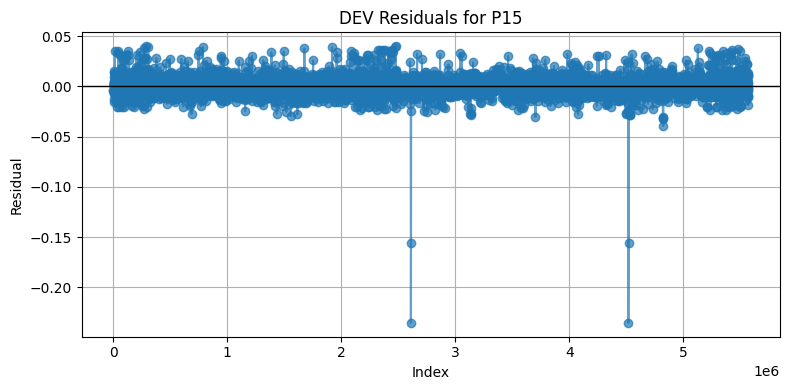

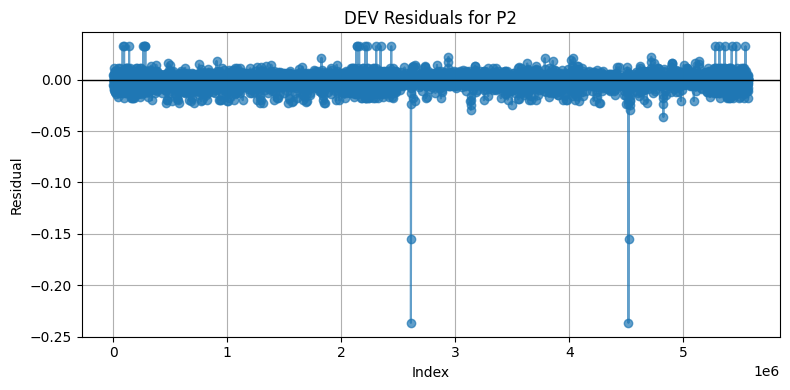

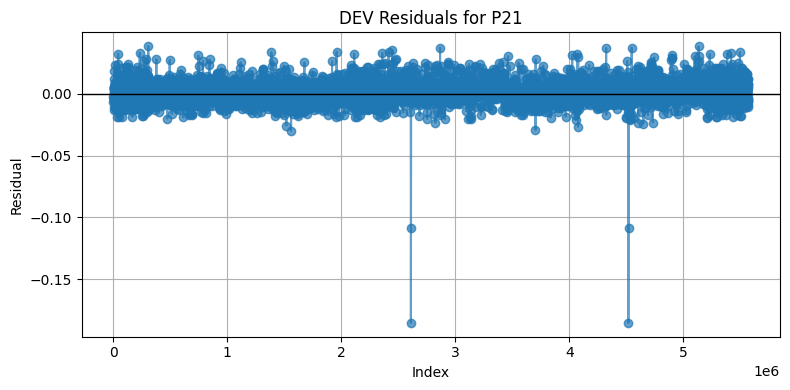

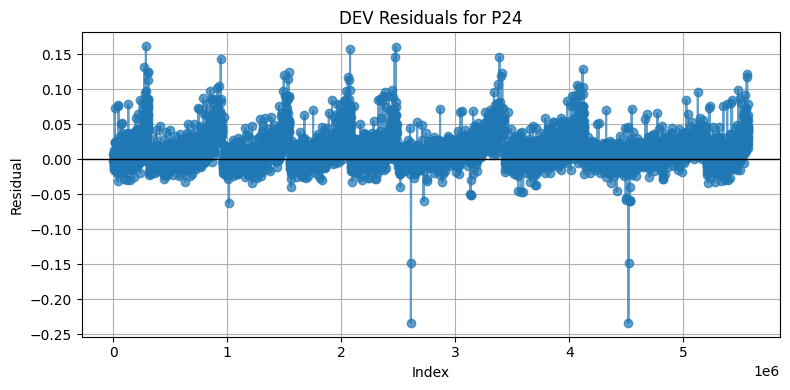

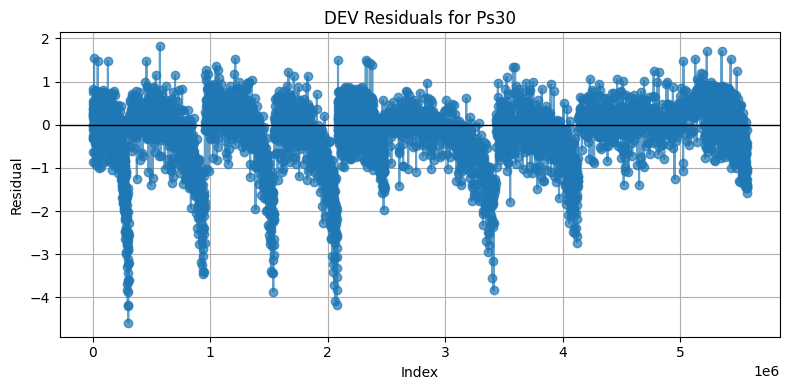

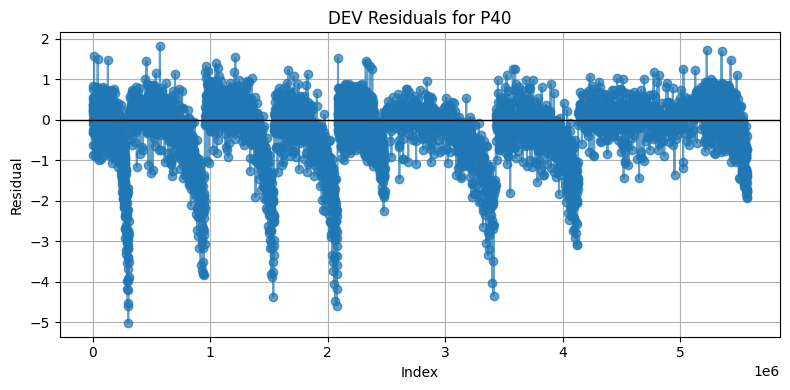

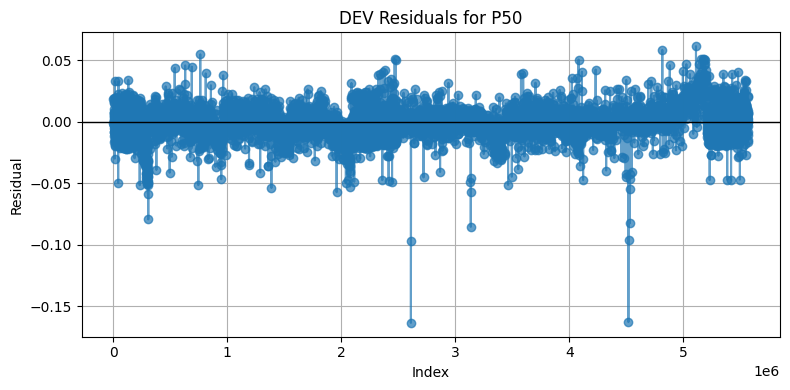

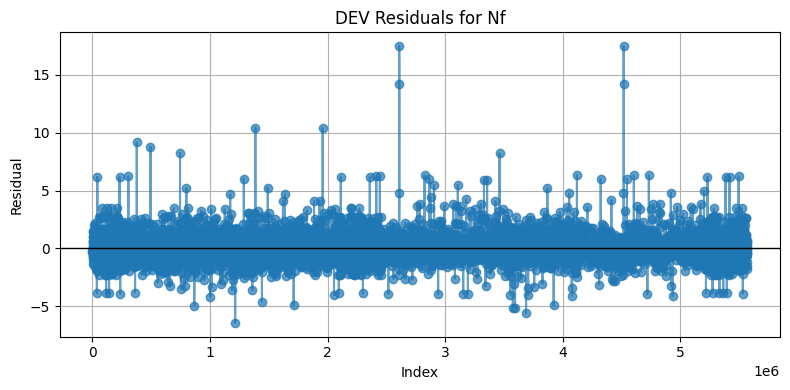

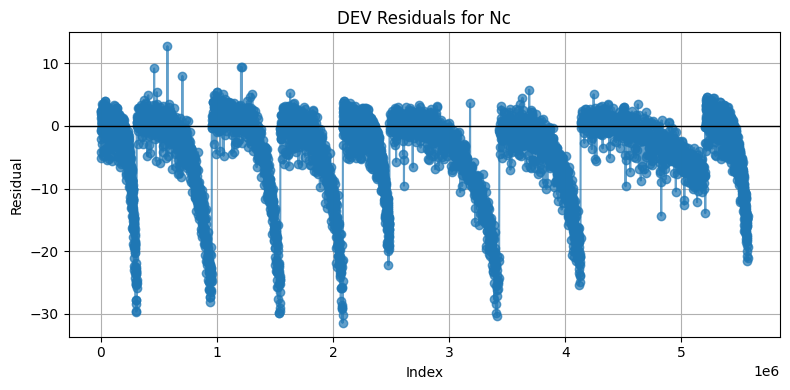

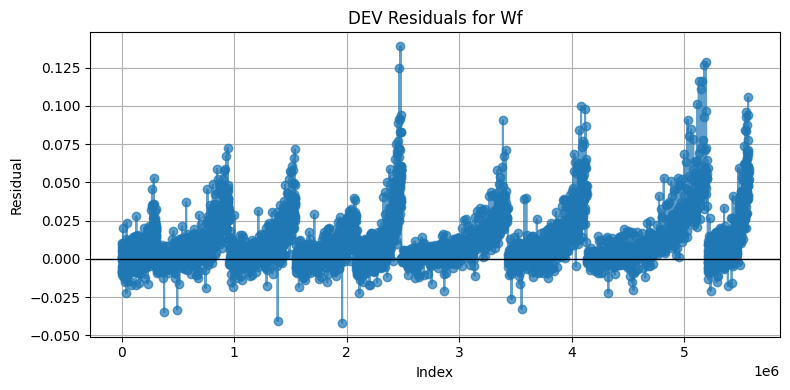

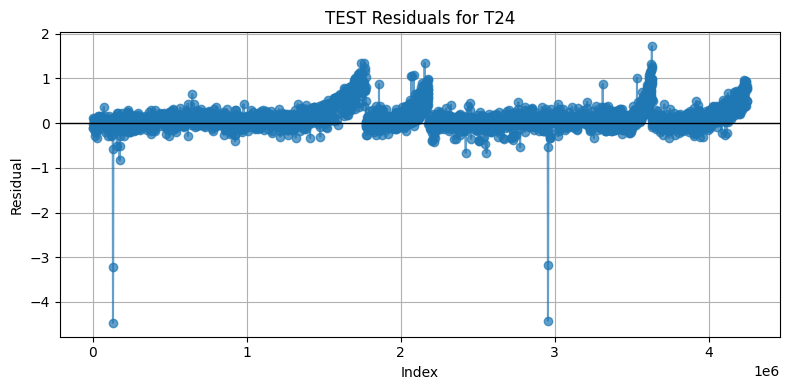

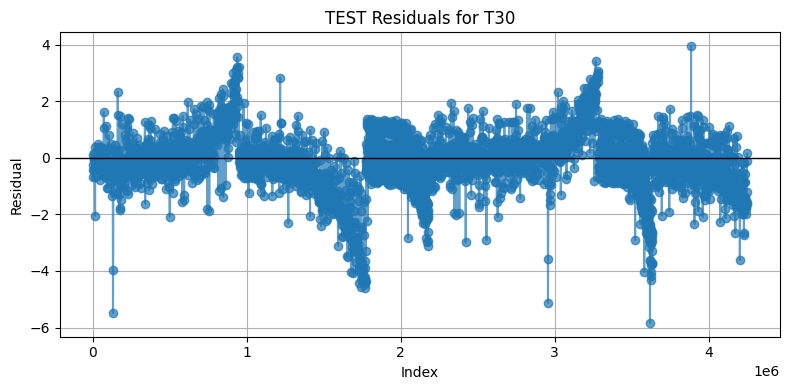

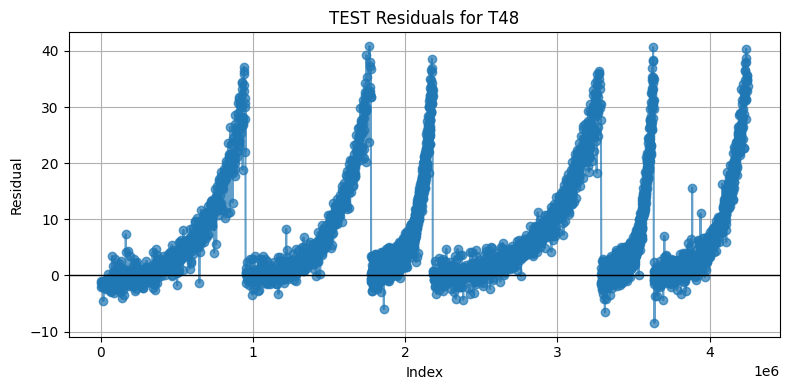

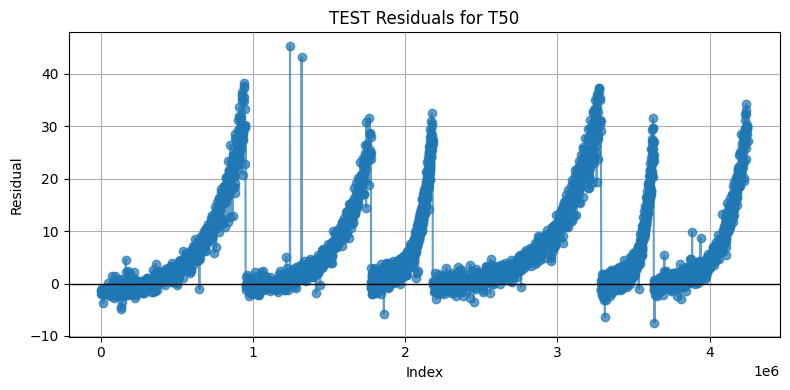

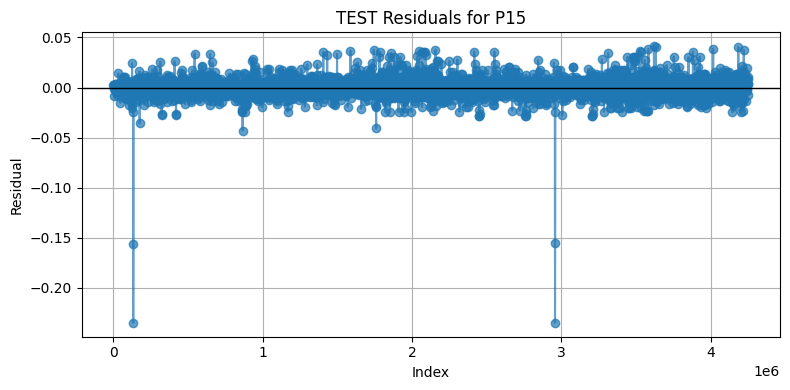

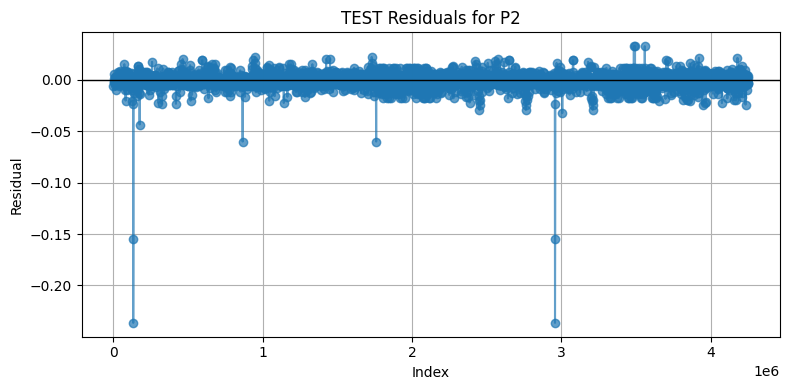

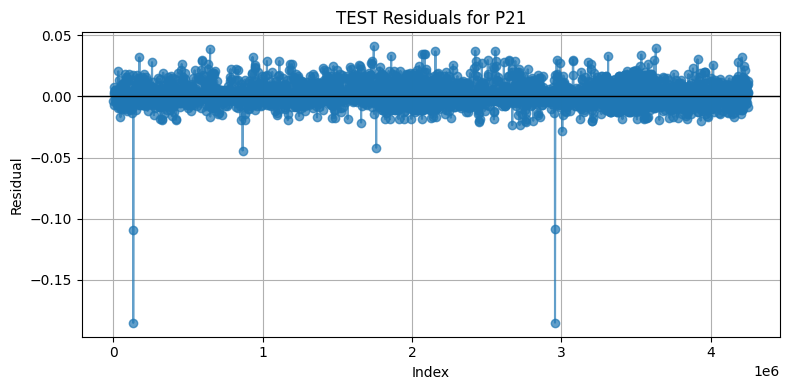

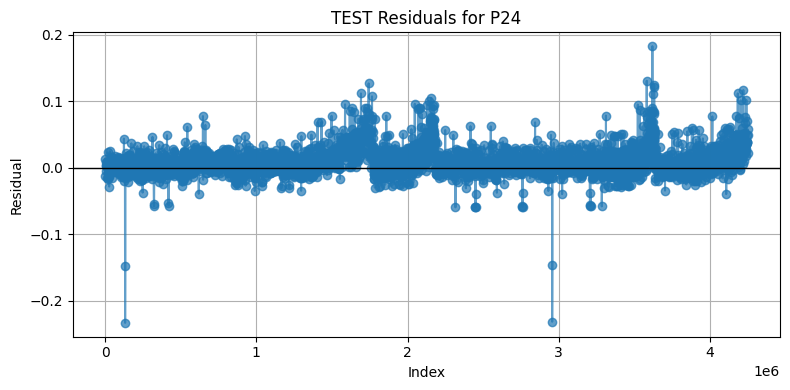

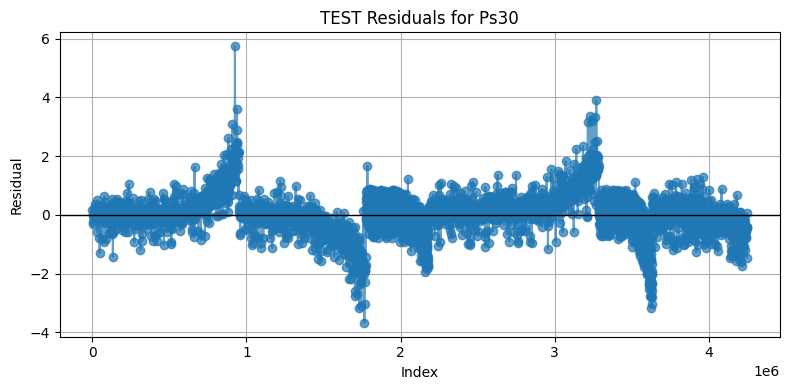

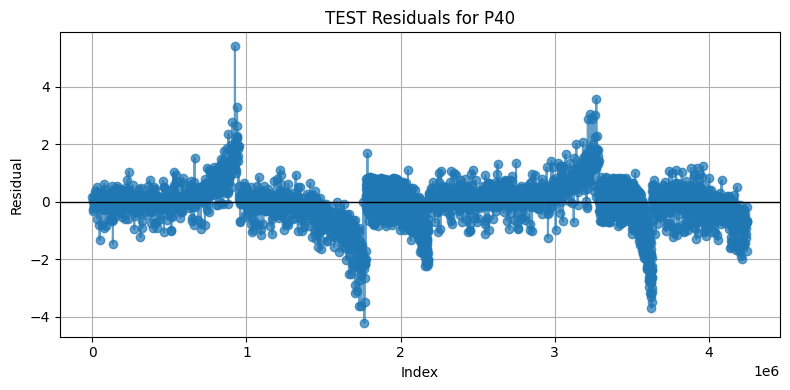

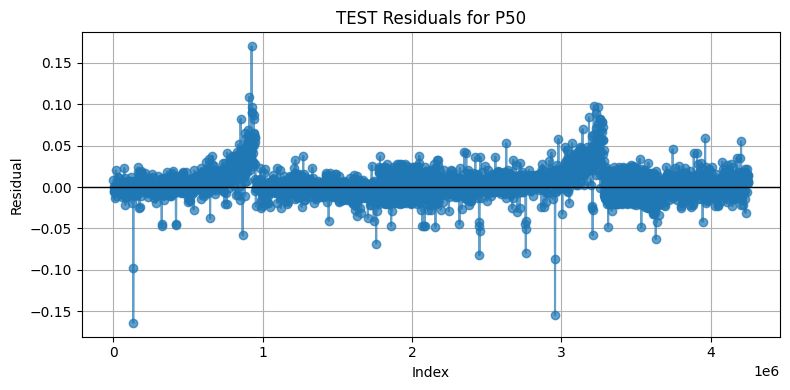

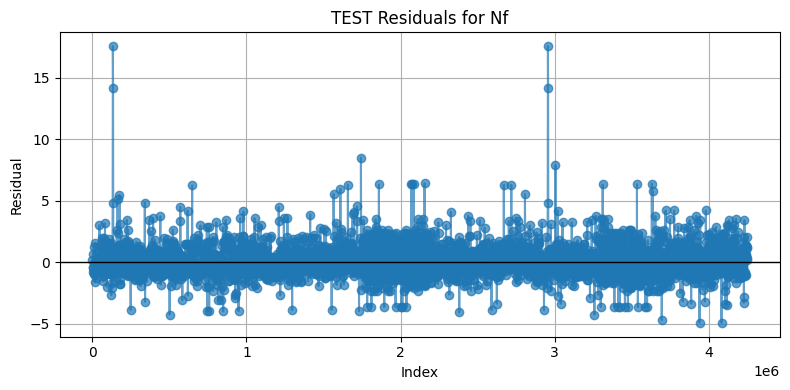

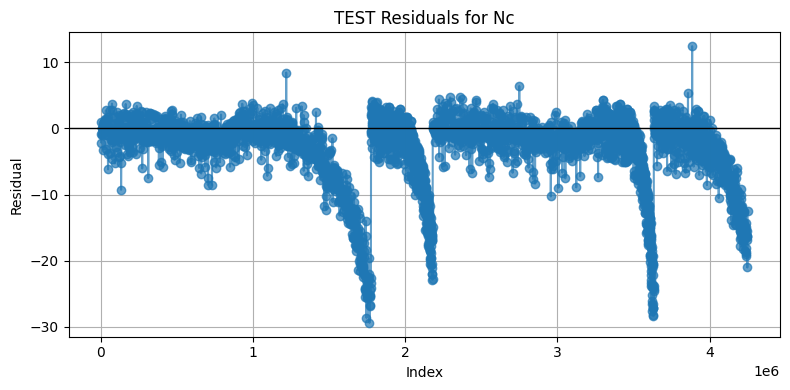

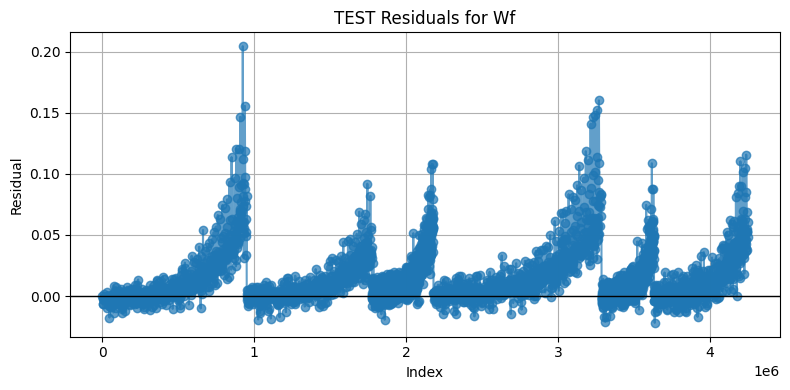

In [5]:
from gp_residuals import run_gp_residuals

result = run_gp_residuals(
    device=device,
    x_dev_normal_scaled=x_dev_normal_scaled,
    y_dev_normal_scaled=y_dev_normal_scaled,
    x_dev_abnormal_scaled=x_dev_abnormal_scaled,
    x_test_abnormal_scaled=x_test_abnormal_scaled,
    y_dev_mean=y_dev_mean,
    y_dev_std=y_dev_std,
    W_dev=W_dev, X_s_dev=X_s_dev, dev_abnormal_idx=dev_abnormal_idx,
    W_test=W_test, X_s_test=X_s_test, test_abnormal_idx=test_abnormal_idx,
    num_iters=100, lr=0.1
)

dev_residuals  = result['dev_residuals']
test_residuals = result['test_residuals']
model          = result['model']
likelihood     = result['likelihood']

In [ ]:
from residual_analysis import compute_residuals_by_unit, show_residual_widgets

result = compute_residuals_by_unit(
    dev_residuals, test_residuals,
    dev_abnormal_idx, test_abnormal_idx,
    A_dev, A_test
)

dev_residuals_by_unit  = result['dev_residuals_by_unit']
test_residuals_by_unit = result['test_residuals_by_unit']
dev_units              = result['dev_units']
test_units             = result['test_units']
output_names_list      = result['output_names_list']

show_residual_widgets(dev_residuals_by_unit, test_residuals_by_unit, dev_units, test_units)

Dropdown(description='Select Dataset:', options=('DEV', 'TEST'), value='DEV')

Dropdown(description='Select Unit:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9), value=1)

Output()

In [8]:
from sensor_processing import select_and_normalize

selected_sensors = ['T48', 'T50', 'Wf']  # 여기서 센서 지정

result = select_and_normalize(
    dev_residuals_by_unit,
    test_residuals_by_unit,
    selected_sensors
)

dev_selected    = result['dev_selected']
test_selected   = result['test_selected']
sensor_stats    = result['sensor_stats']
dev_normalized  = result['dev_normalized']
test_normalized = result['test_normalized']

engine_data_list = []
for unit in sorted(dev_normalized.keys()):
    unit_dict = dev_normalized[unit]
    cycles = sorted(next(iter(unit_dict.values())).keys())
    data = np.array([
        [unit_dict[name][cycle] for name in selected_sensors]
        for cycle in cycles
    ])
    engine_data_list.append(data)

# print("debug")

T48: mean=6.1158, std=8.3192
T50: mean=4.8423, std=6.7186
Wf: mean=0.0102, std=0.0133



lambda1=6.0, lambda2=2.0
Debug epochs: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Number of engines: 9
  Engine 1: 72 cycles
  Engine 2: 73 cycles
  Engine 3: 67 cycles
  Engine 4: 60 cycles
  Engine 5: 93 cycles
  Engine 6: 63 cycles
  Engine 7: 80 cycles
  Engine 8: 71 cycles
  Engine 9: 84 cycles

EPOCH 100 - LOSS COMPUTATION

[Engine 1] T_n=72
  HI range: [0.089744, 0.226849]
  HI[0] (first): 0.099536
  HI[71] (last): 0.225550
  Loss Term 1 contribution: 0.599773 (target: h_n(T_n)=1)
  Loss Term 2 contribution: 0.002426
  Monotonicity violations: 32/71
  Loss Term 3 contribution: 0.005889
  Convexity violations: 34/70
  Gradient (dHI/dt) stats:
    Mean: 0.001775, Std: 0.008128

[Engine 2] T_n=73
  HI range: [0.093070, 0.252602]
  HI[0] (first): 0.096352
  HI[72] (last): 0.248655
  Loss Term 1 contribution: 0.564519 (target: h_n(T_n)=1)
  Loss Term 2 contribution: 0.001873
  Monotonicity violations: 25/72
  Loss Term 3 contribution: 0.004784
  Convexity violations: 34/71


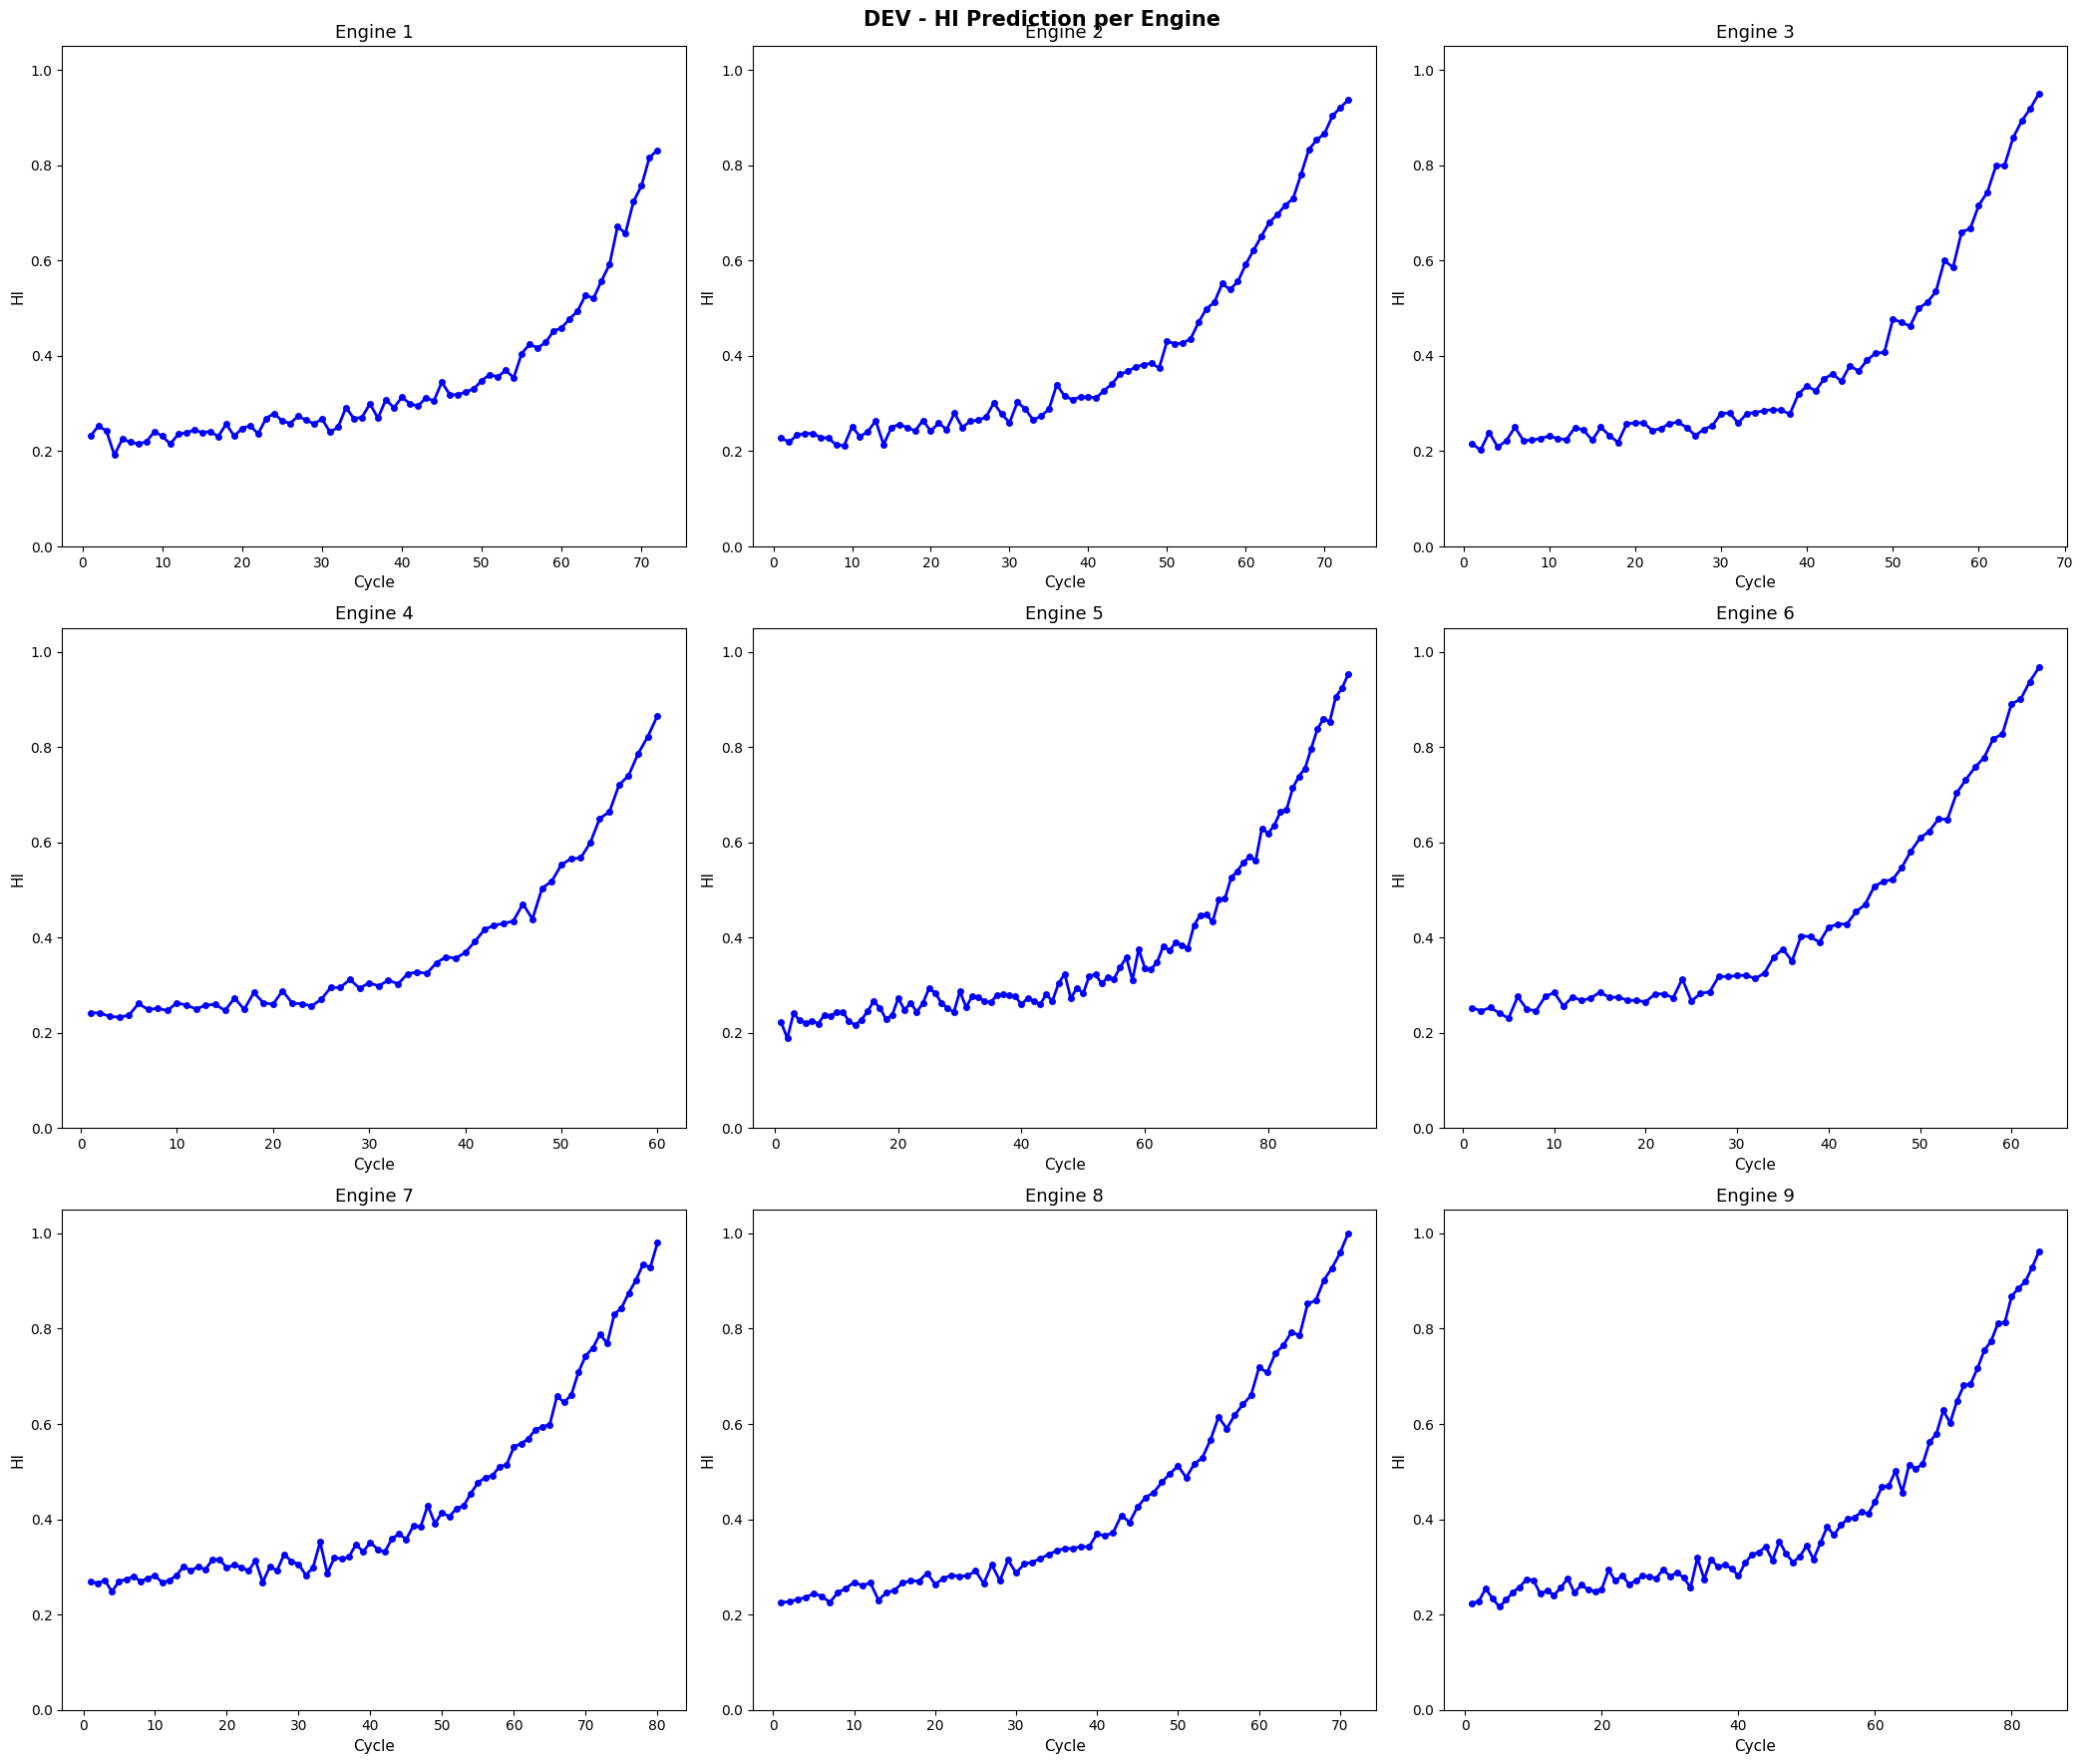

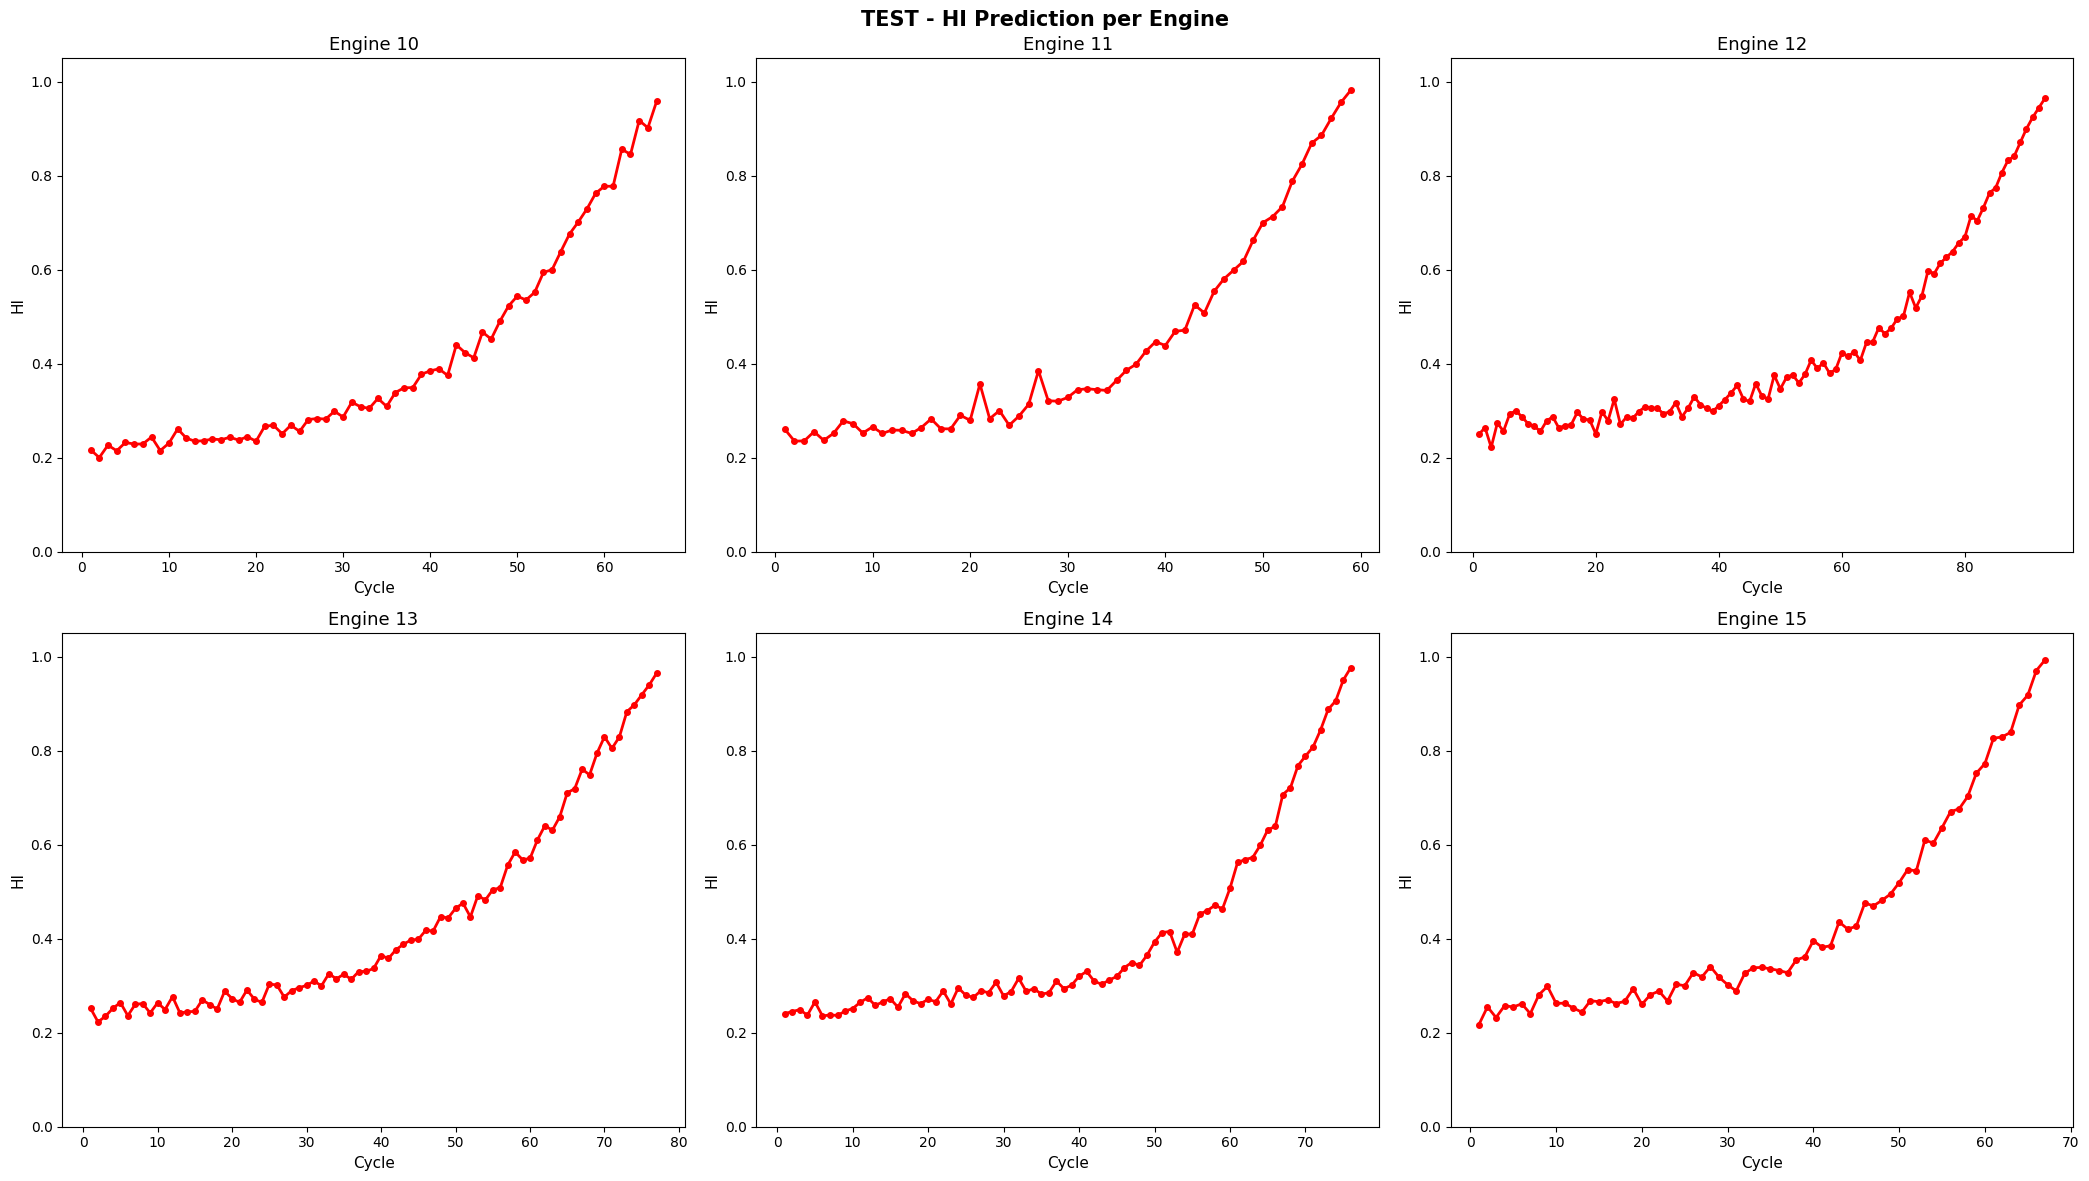

In [9]:
from neural_fusion import train_model, predict
from visualisation import plot_HI_curves

# 여기서 직접 설정
lambda1 = 6.0
lambda2 = 2.0
epochs  = 1000

print(f"\n{'='*60}")
print(f"lambda1={lambda1}, lambda2={lambda2}")
print(f"{'='*60}")

model, loss_history = train_model(
    engine_data_list,
    epochs=epochs,
    lambda0=1.0,
    lambda1=lambda1,
    lambda2=lambda2,
    init_threshold=0.2,
    alpha=0.001,
    verbose=True,
    print_every=100
)

print(f"Final Loss: {loss_history[-1]:.6f}")

plot_HI_curves(
    model=model,
    dev_normalized=dev_normalized,
    test_normalized=test_normalized,
    selected_sensors=selected_sensors,
    loss_history=loss_history
)


[1/16] lambda1=6.0, lambda2=1.0, epochs=1000
Final Loss: 0.450506


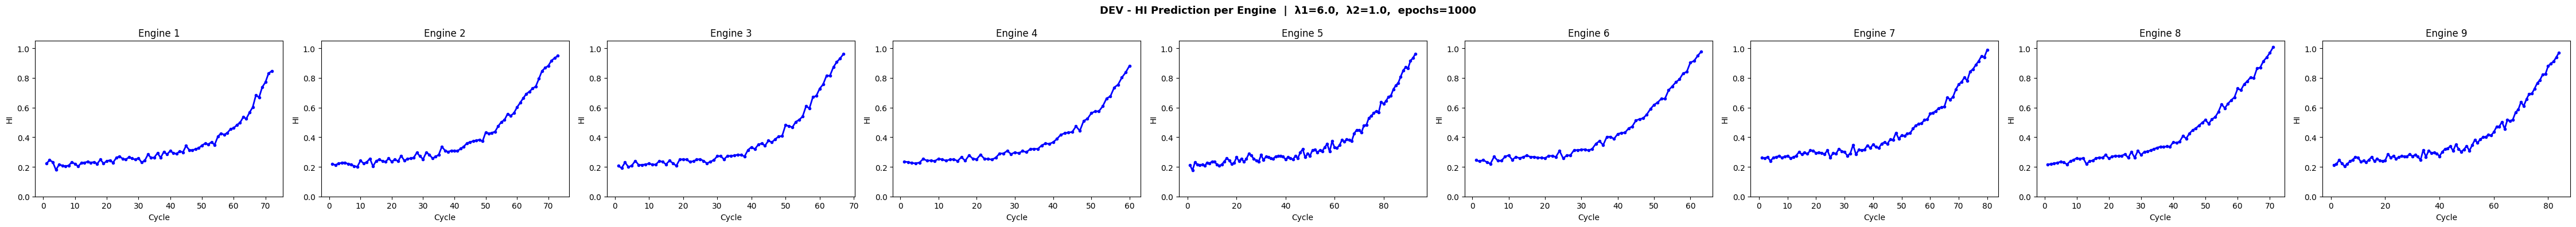

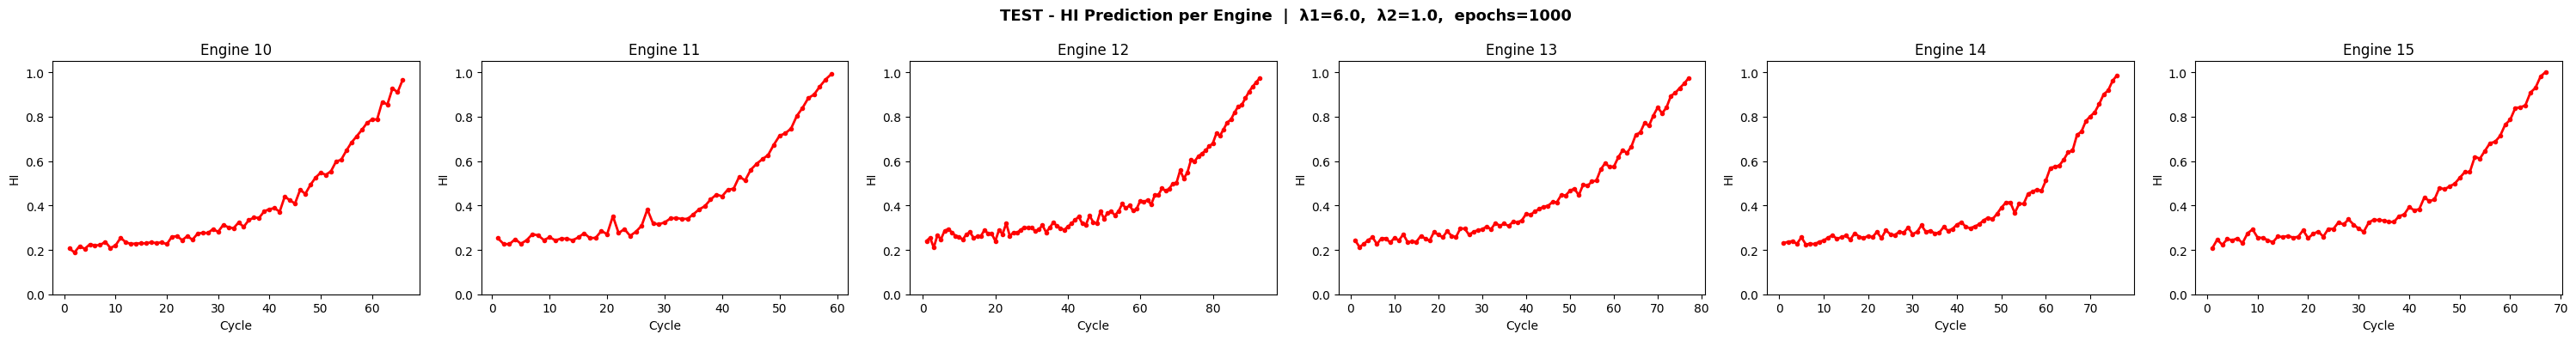


[2/16] lambda1=6.0, lambda2=1.5, epochs=1000
Final Loss: 0.493421


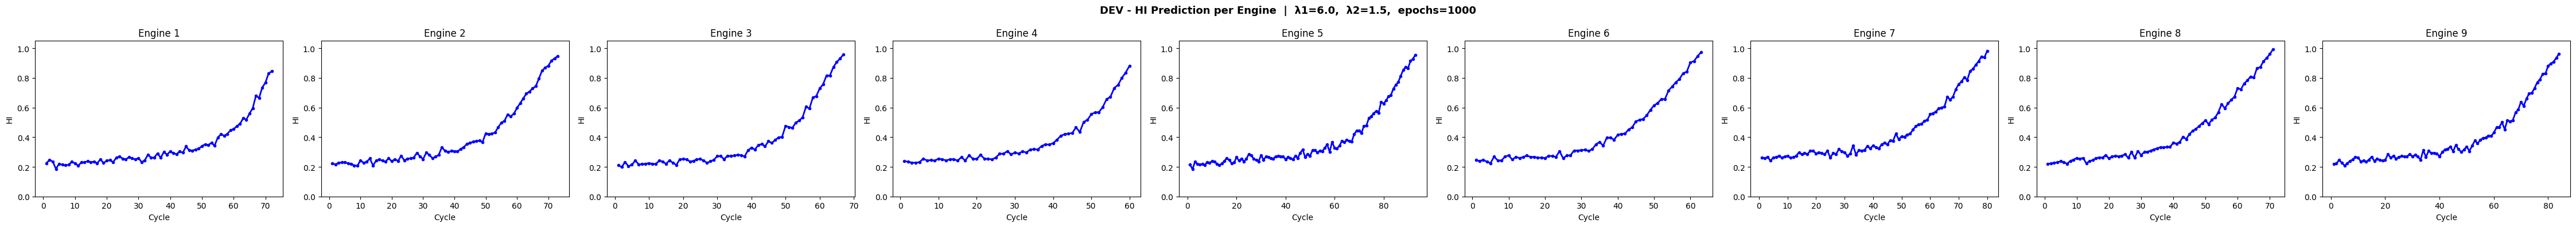

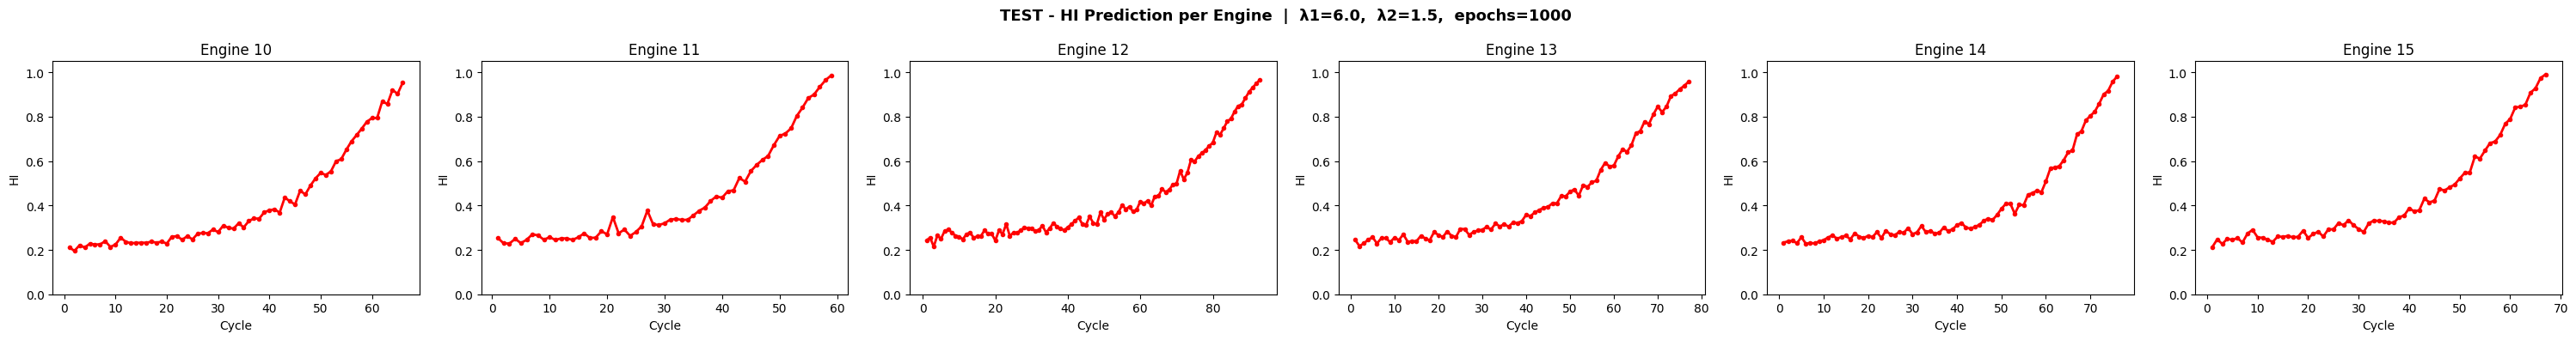


[3/16] lambda1=6.0, lambda2=2.0, epochs=1000
Final Loss: 0.574042


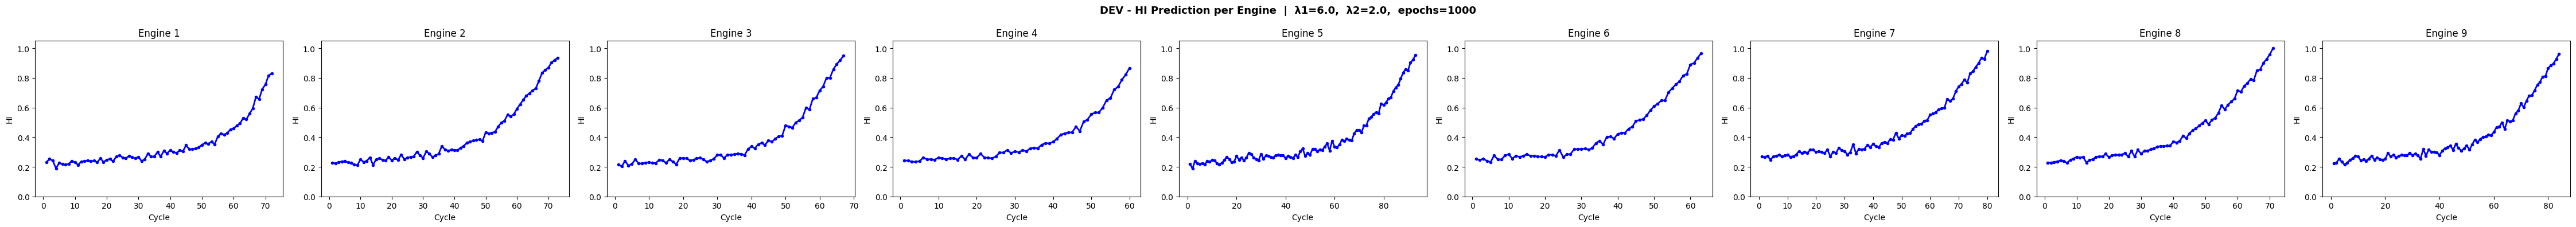

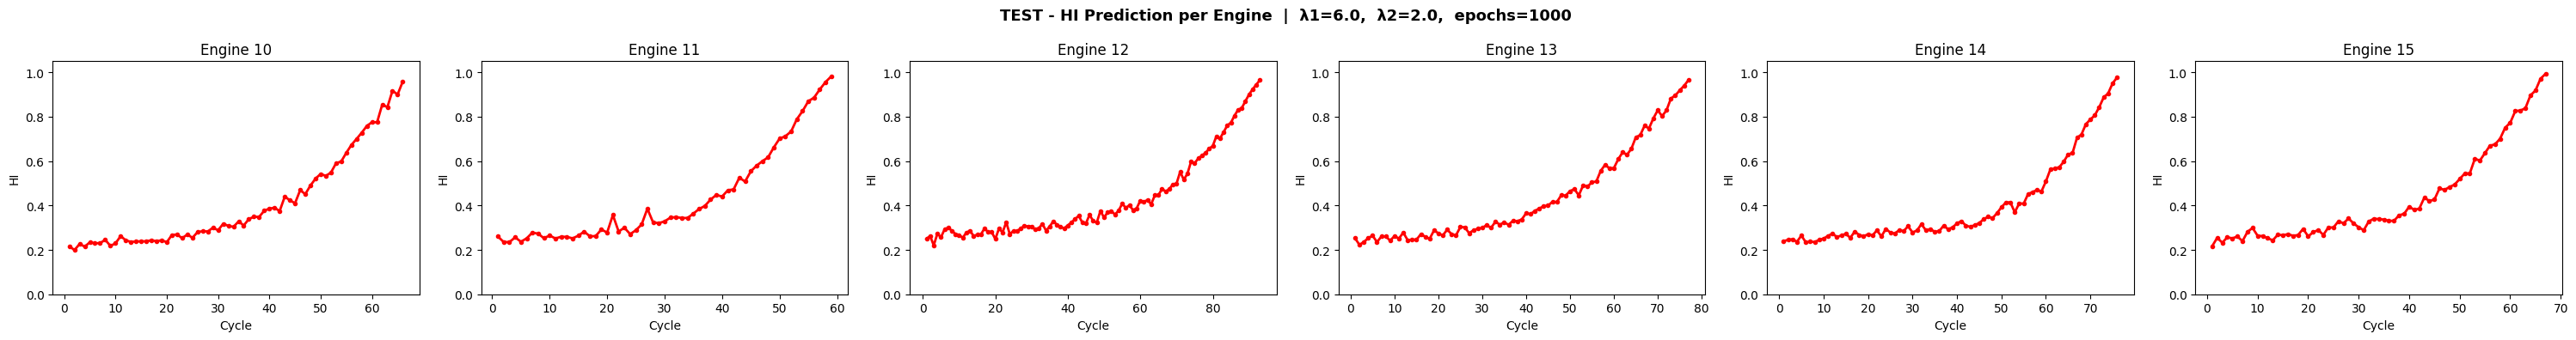


[4/16] lambda1=6.0, lambda2=2.5, epochs=1000
Final Loss: 0.629130


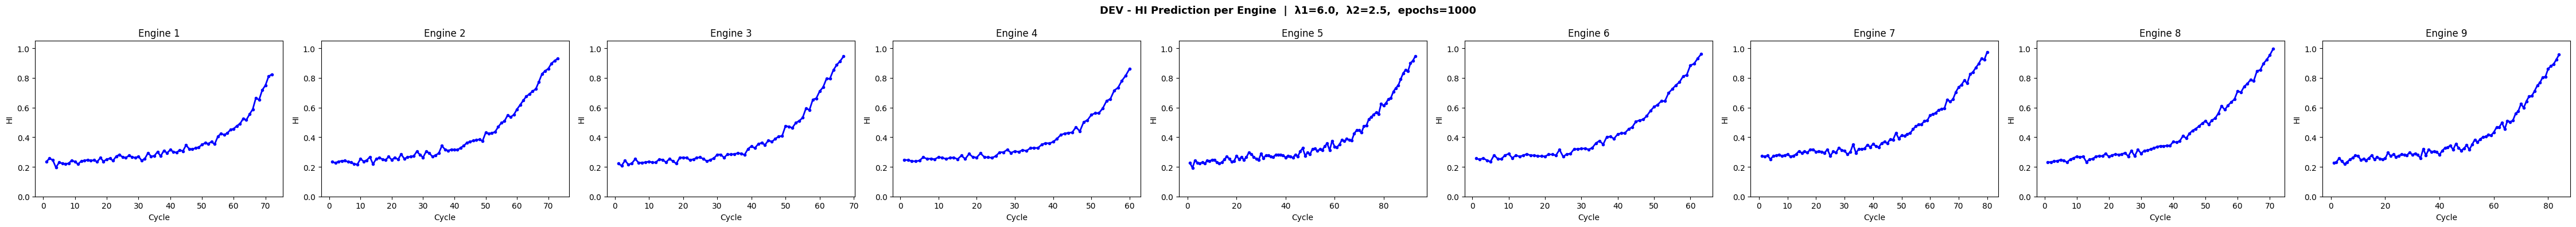

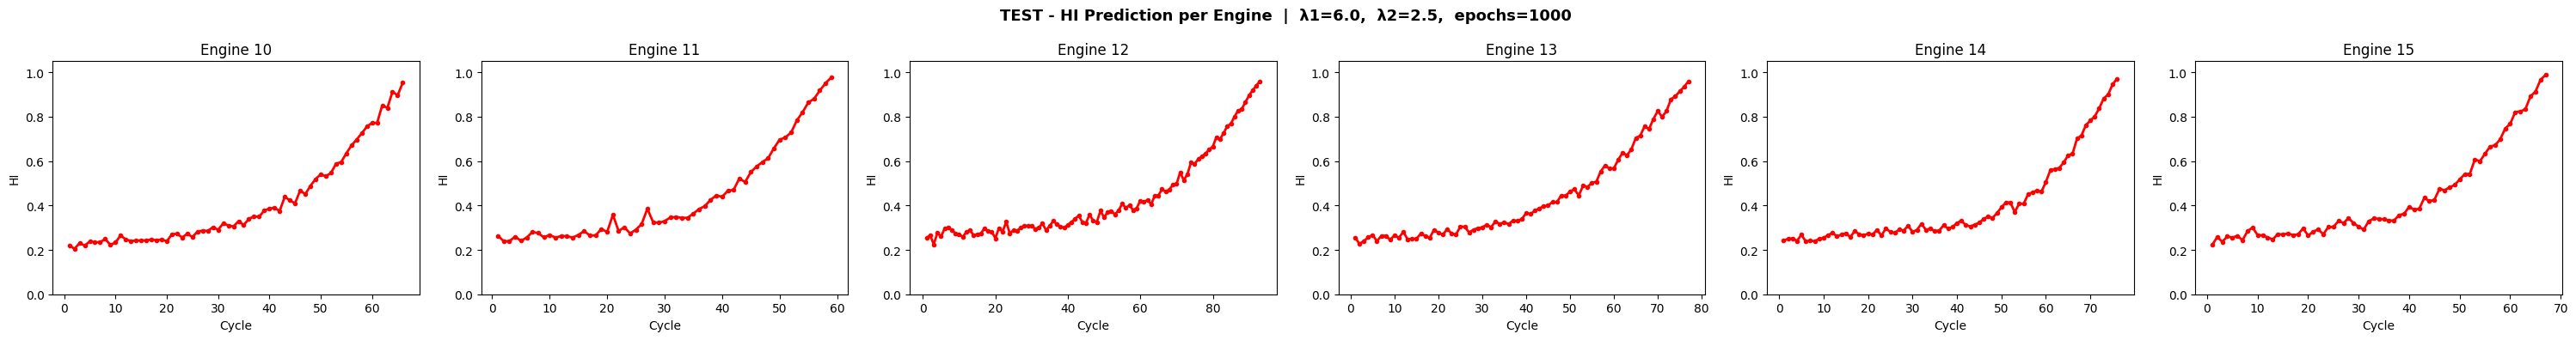


[5/16] lambda1=6.5, lambda2=1.0, epochs=1000
Final Loss: 0.455046


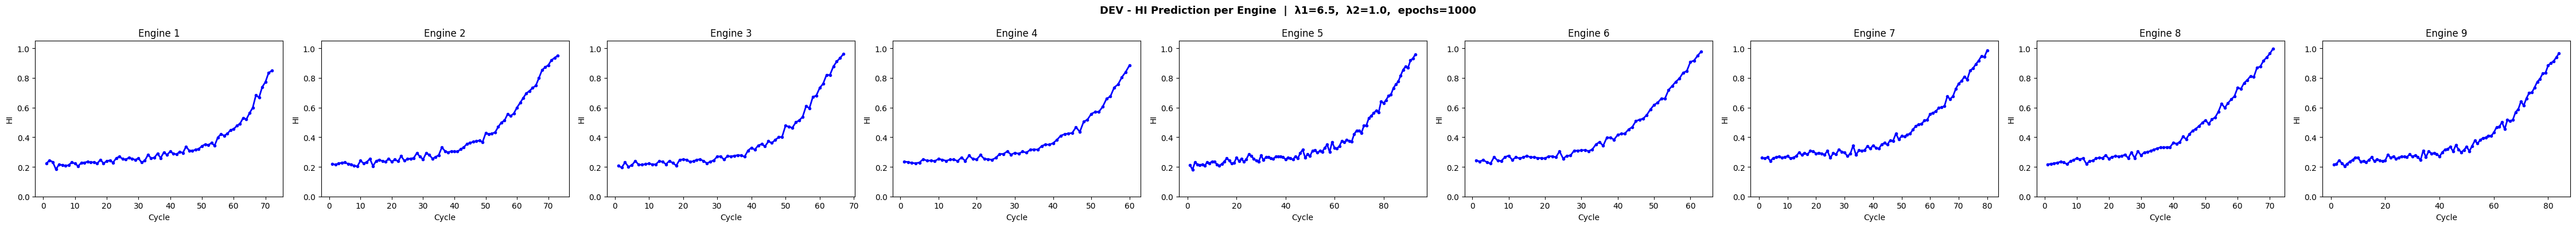

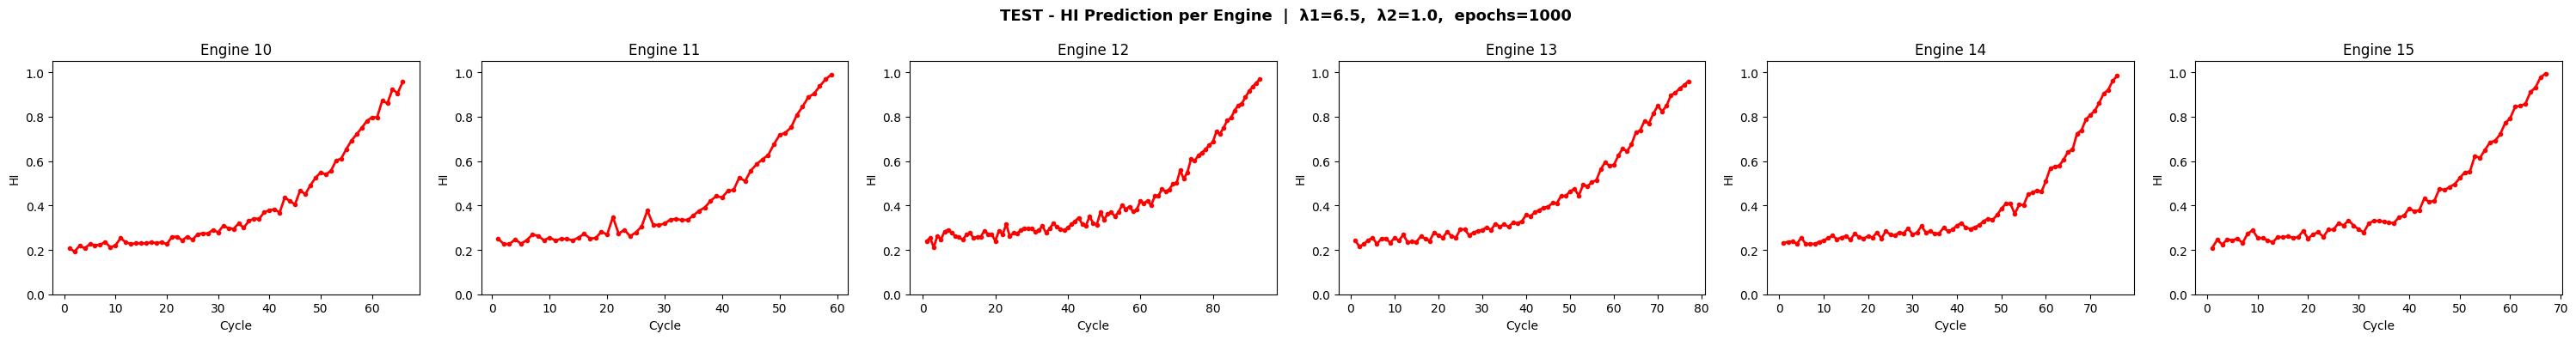


[6/16] lambda1=6.5, lambda2=1.5, epochs=1000
Final Loss: 0.529122


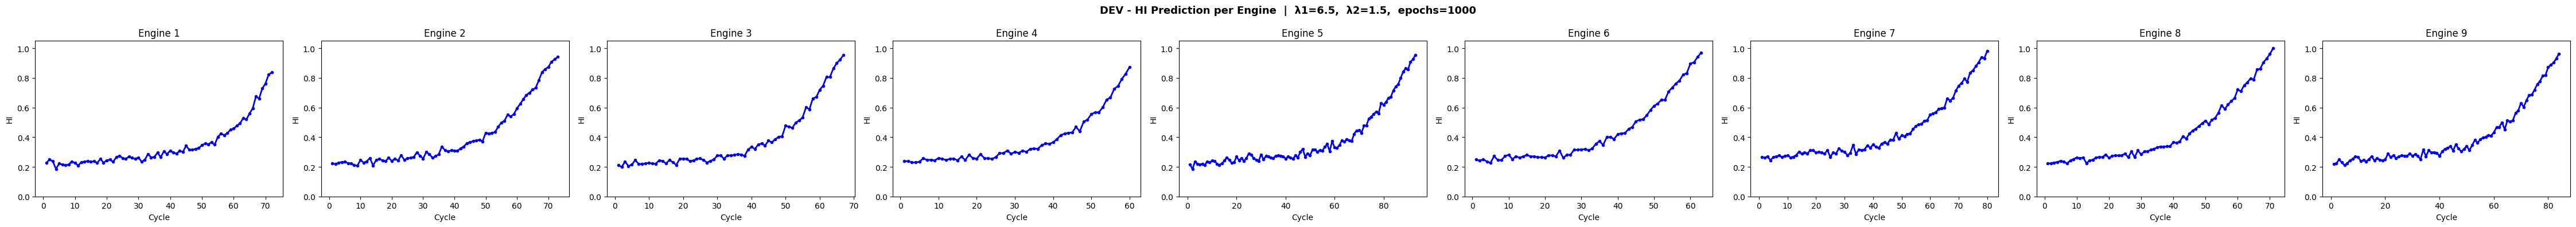

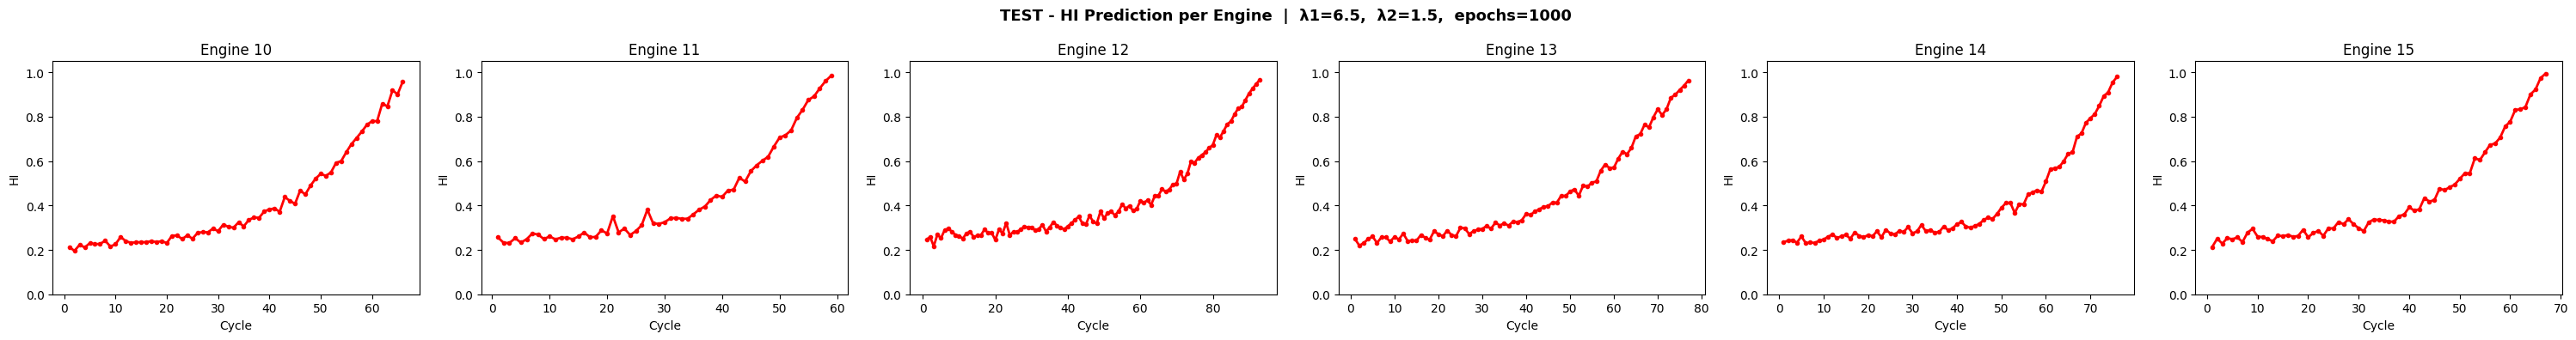


[7/16] lambda1=6.5, lambda2=2.0, epochs=1000
Final Loss: 0.583427


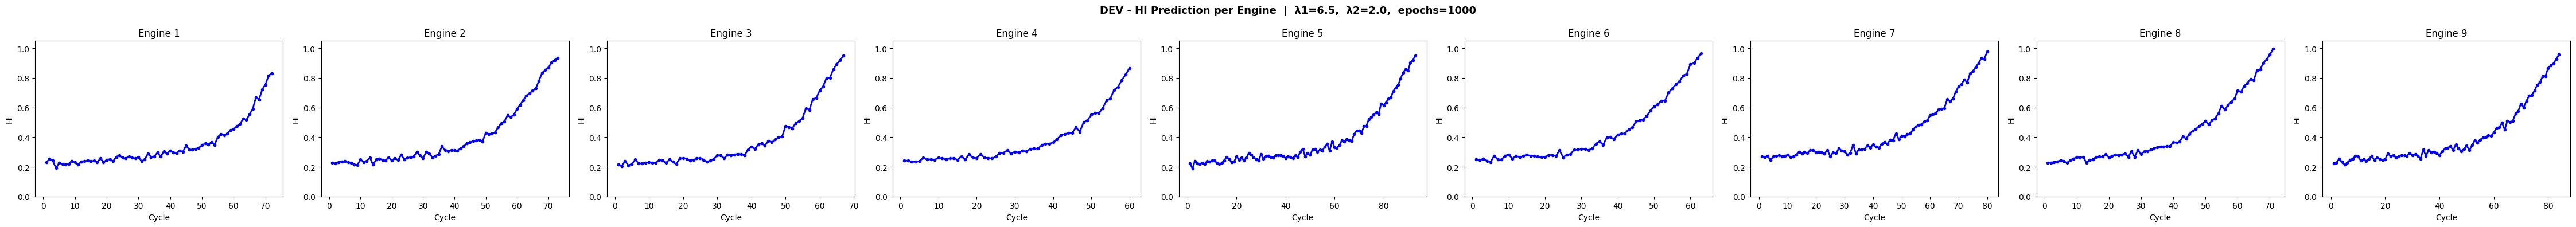

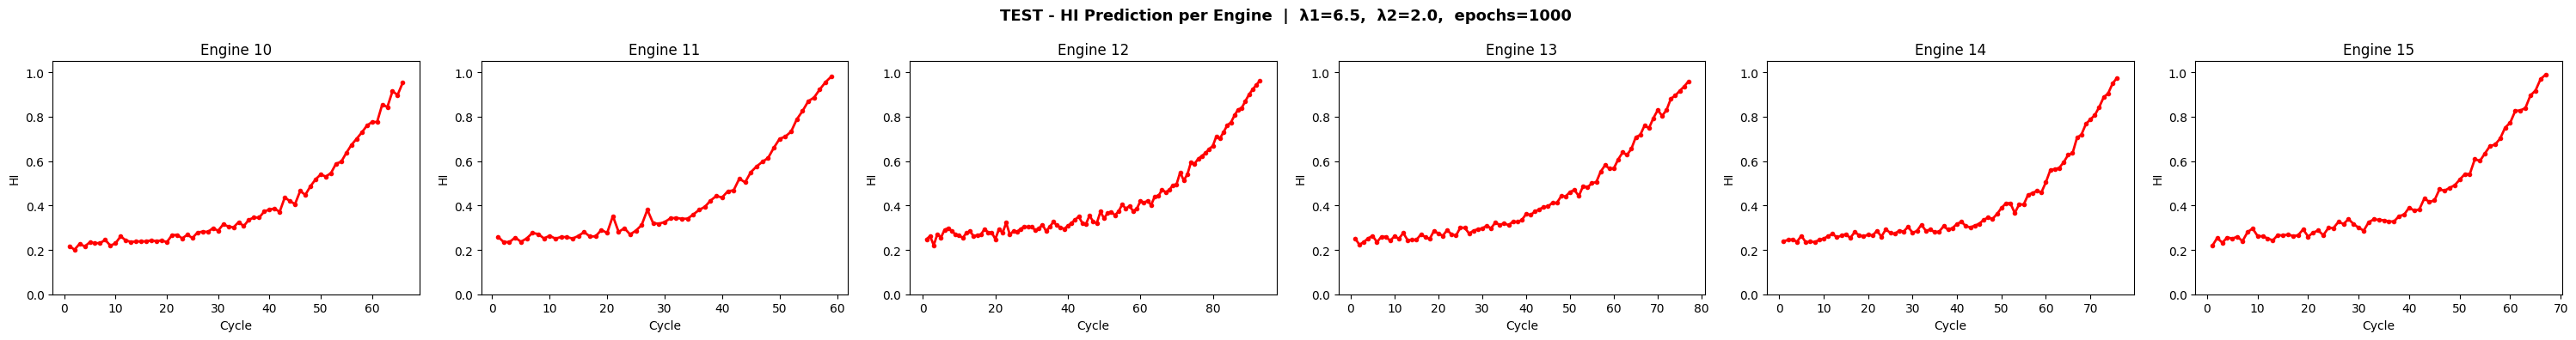


[8/16] lambda1=6.5, lambda2=2.5, epochs=1000
Final Loss: 0.642616


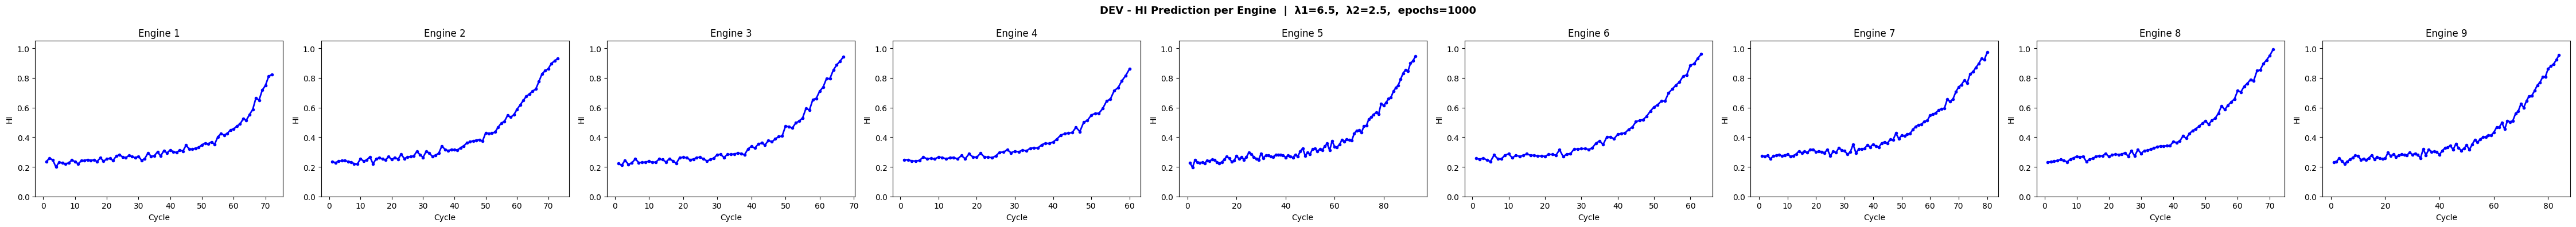

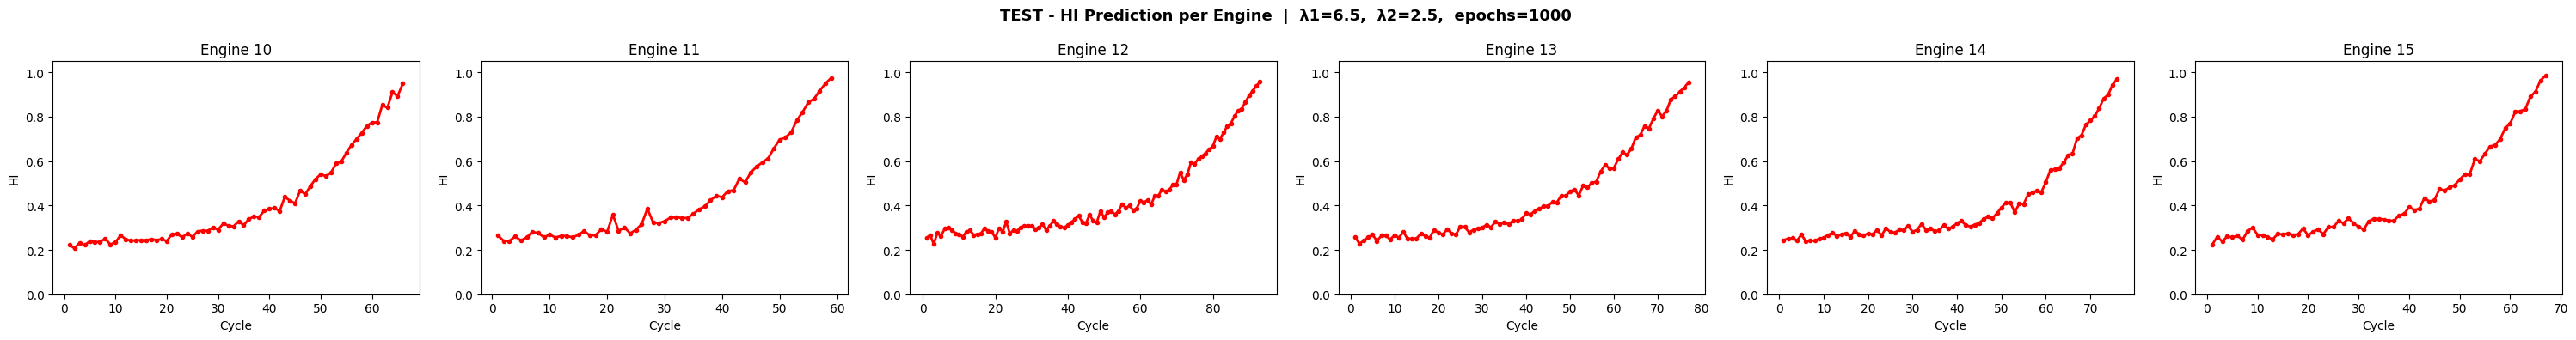


[9/16] lambda1=7.0, lambda2=1.0, epochs=1000
Final Loss: 0.488101


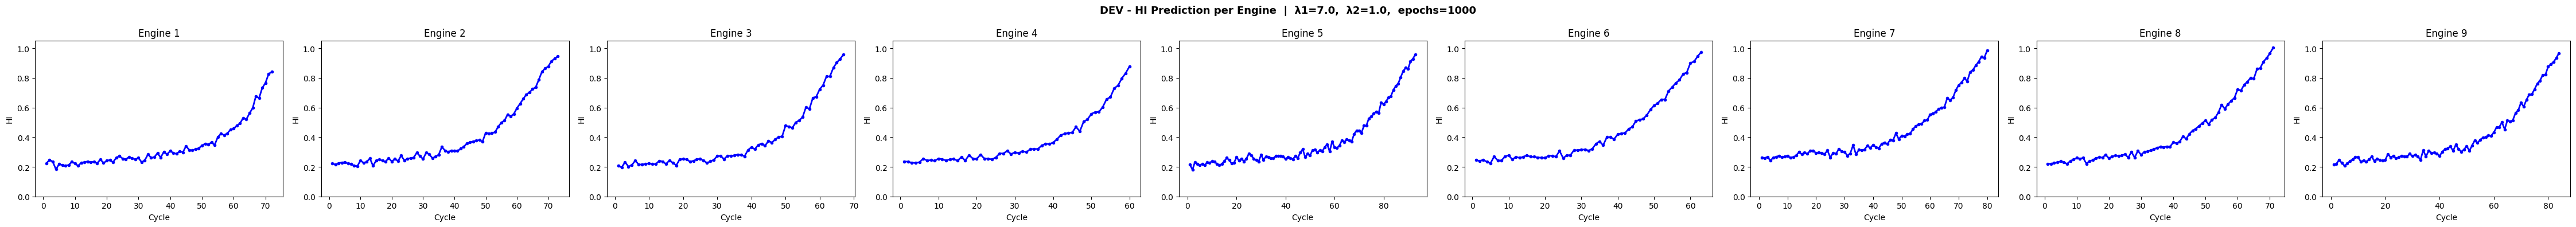

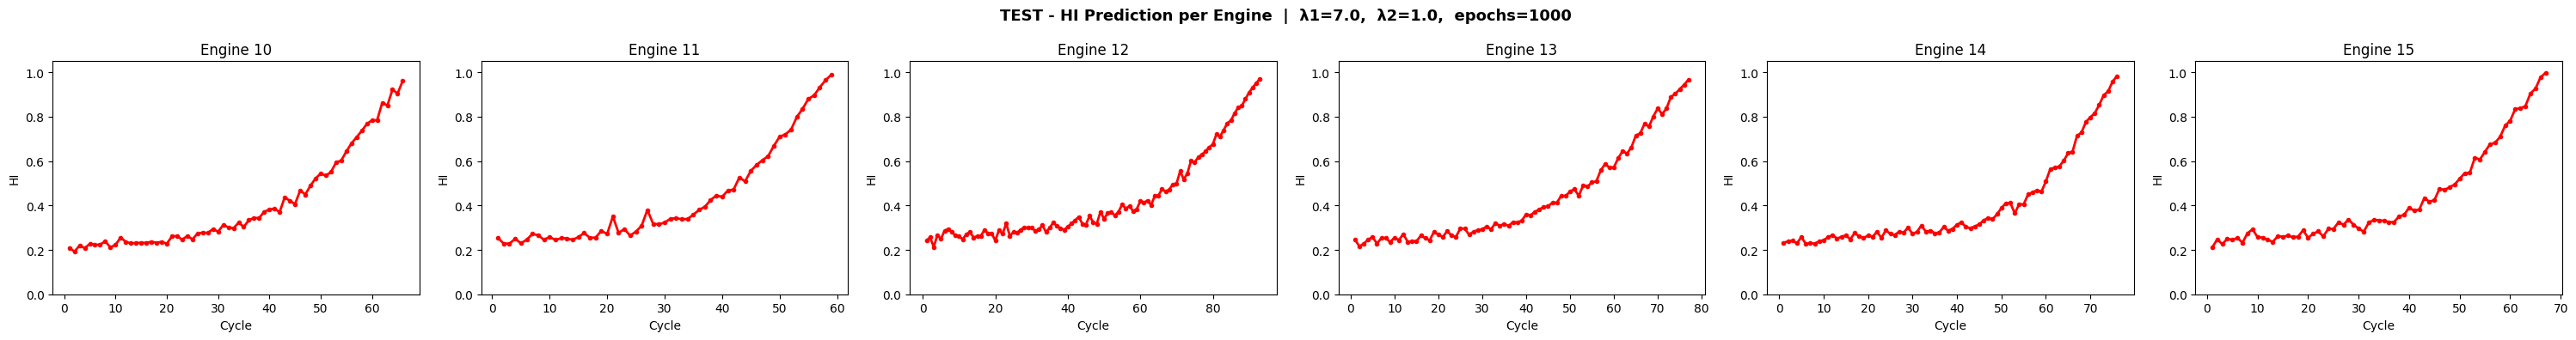


[10/16] lambda1=7.0, lambda2=1.5, epochs=1000
Final Loss: 0.546566


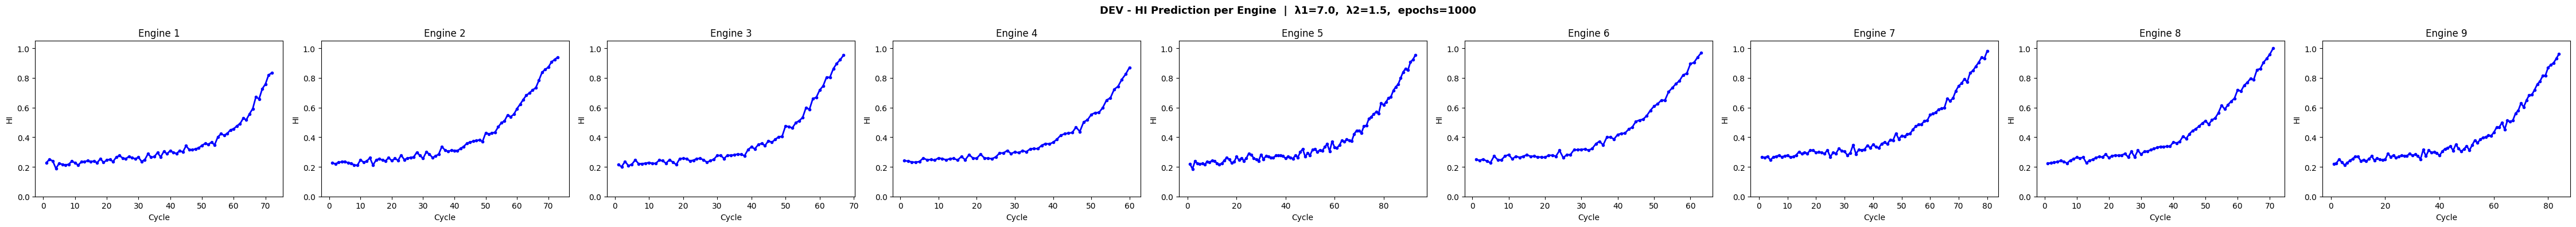

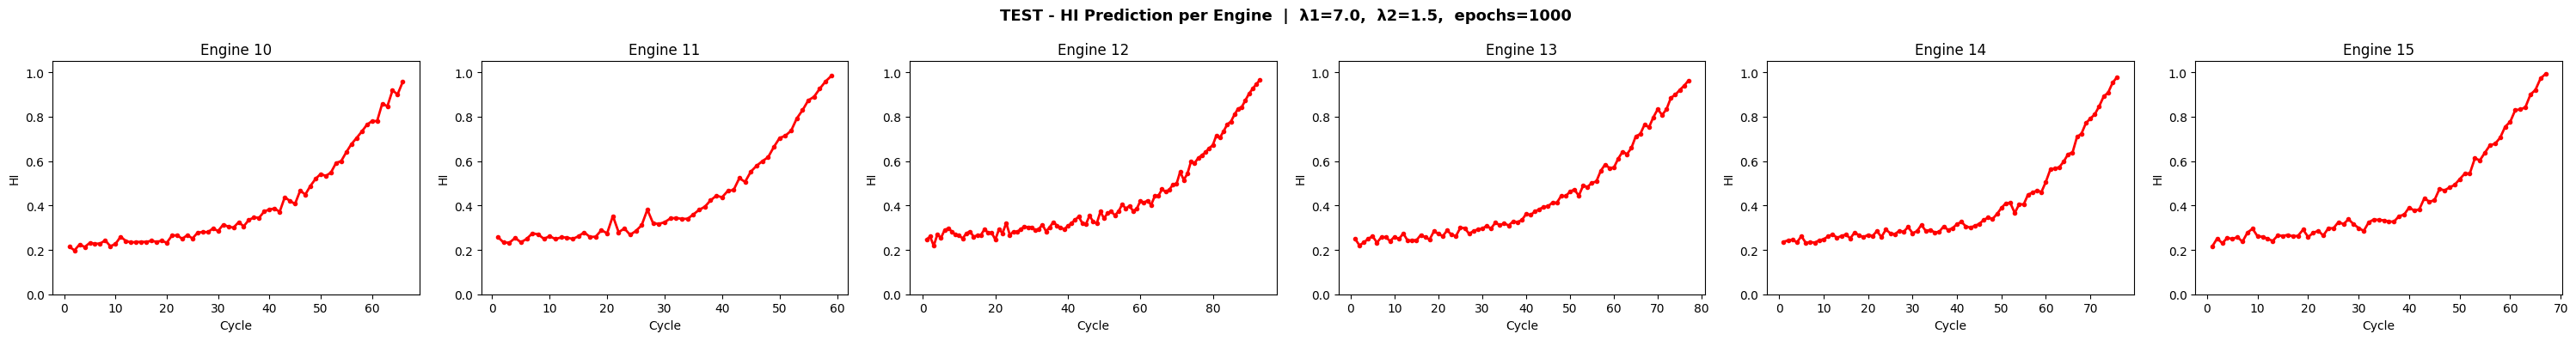


[11/16] lambda1=7.0, lambda2=2.0, epochs=1000
Final Loss: 0.607535


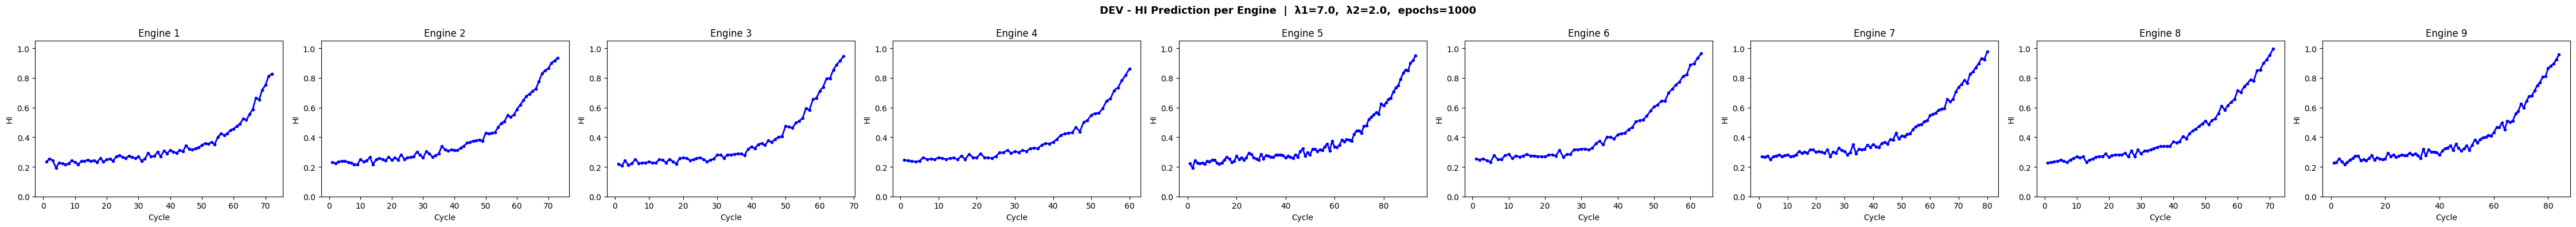

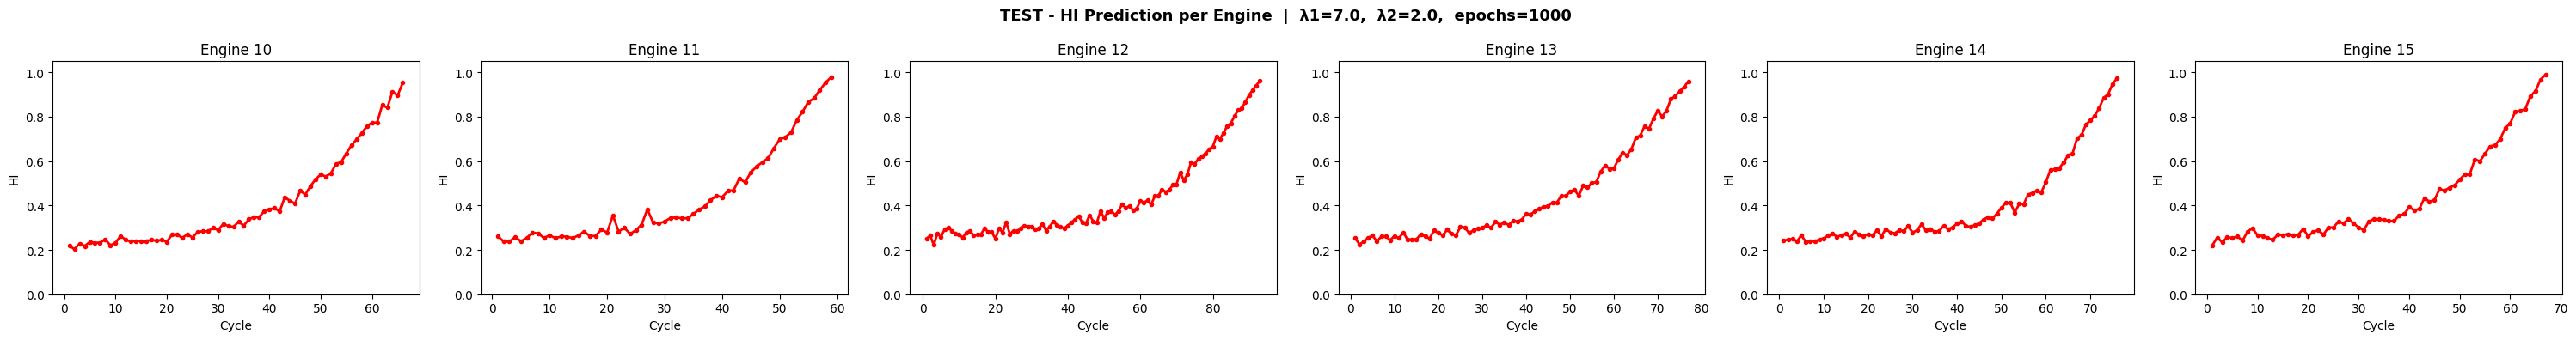


[12/16] lambda1=7.0, lambda2=2.5, epochs=1000
Final Loss: 0.668915


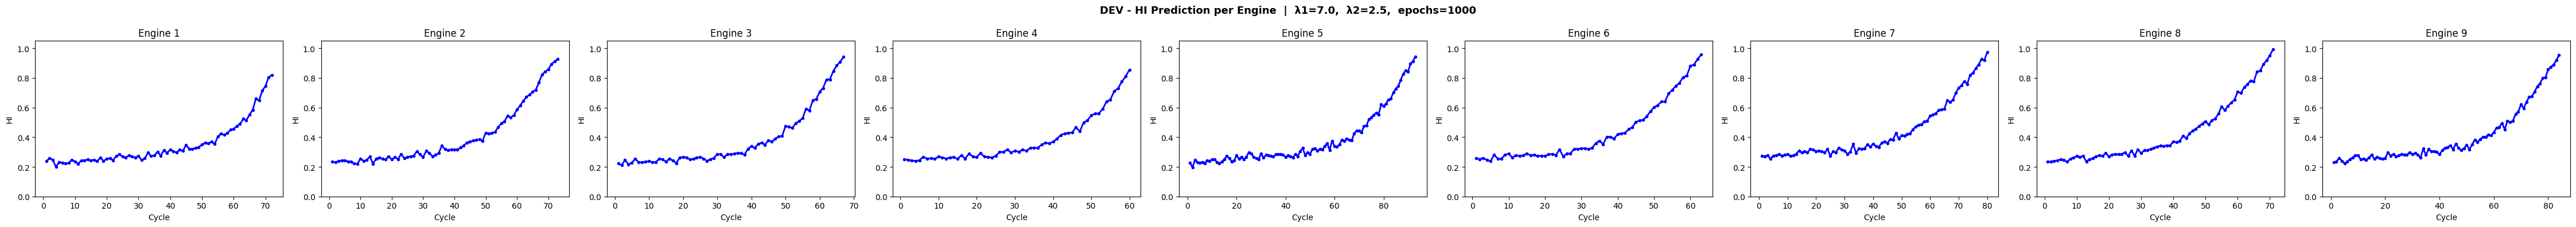

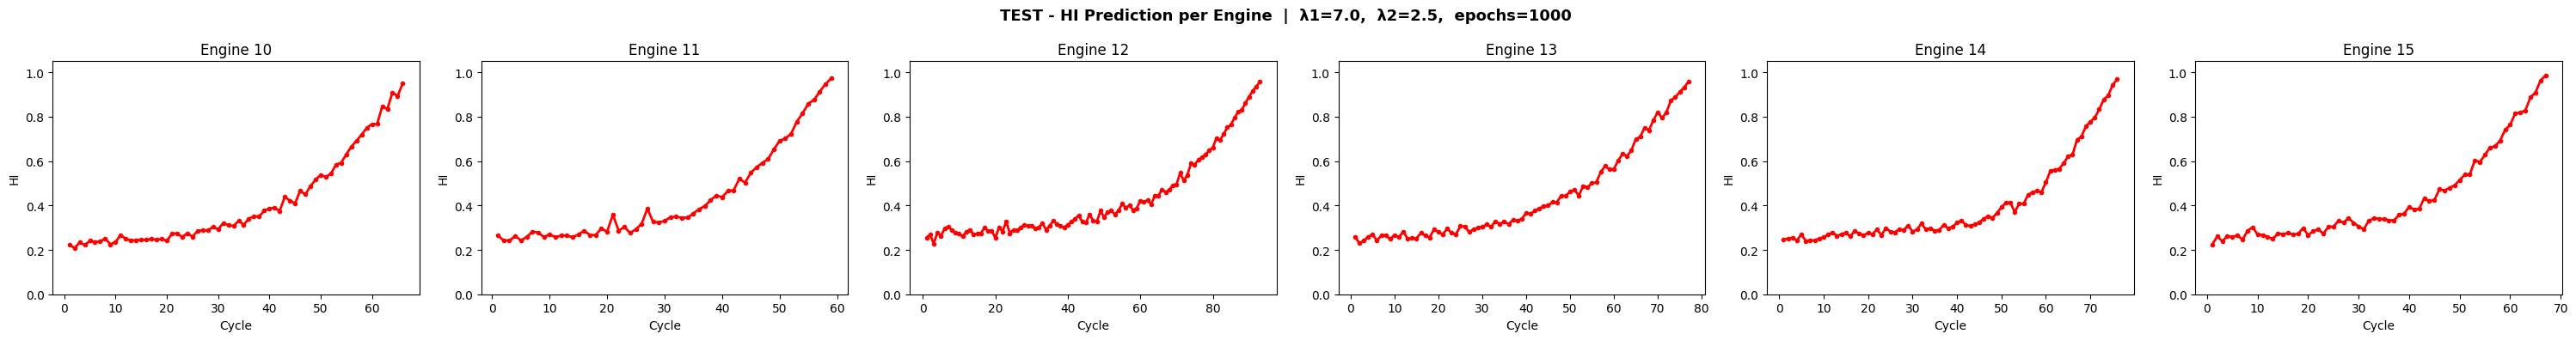


[13/16] lambda1=7.5, lambda2=1.0, epochs=1000
Final Loss: 0.515309


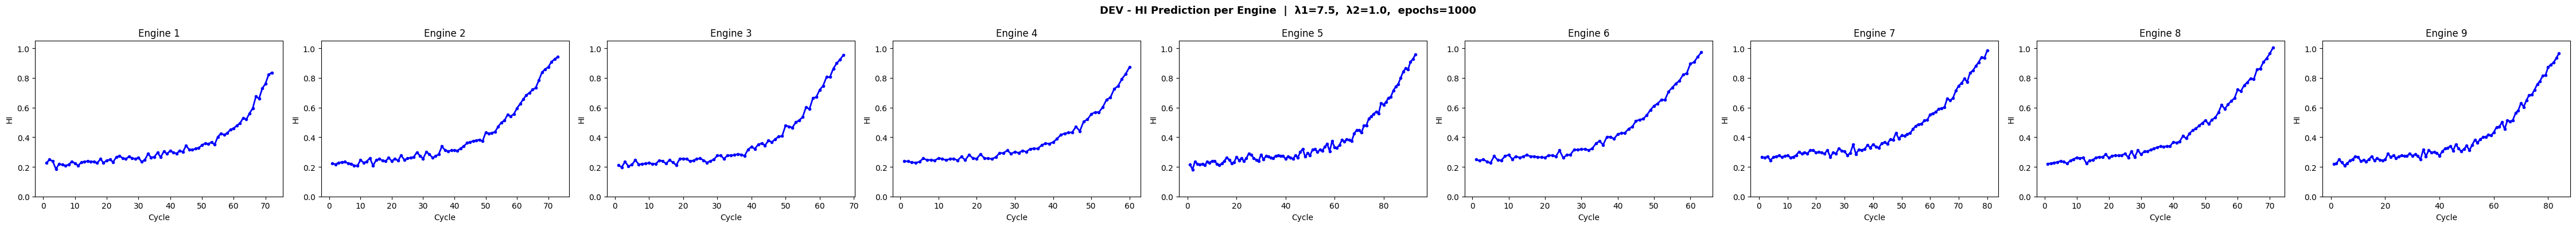

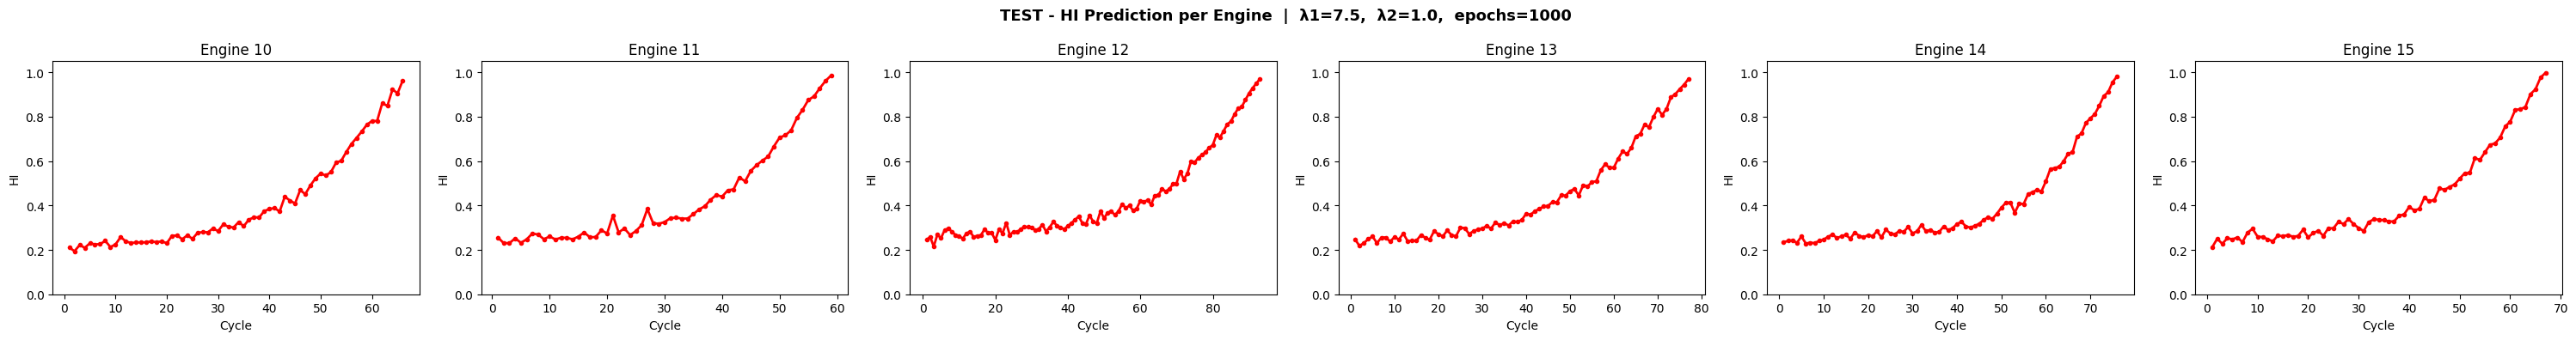


[14/16] lambda1=7.5, lambda2=1.5, epochs=1000
Final Loss: 0.569203


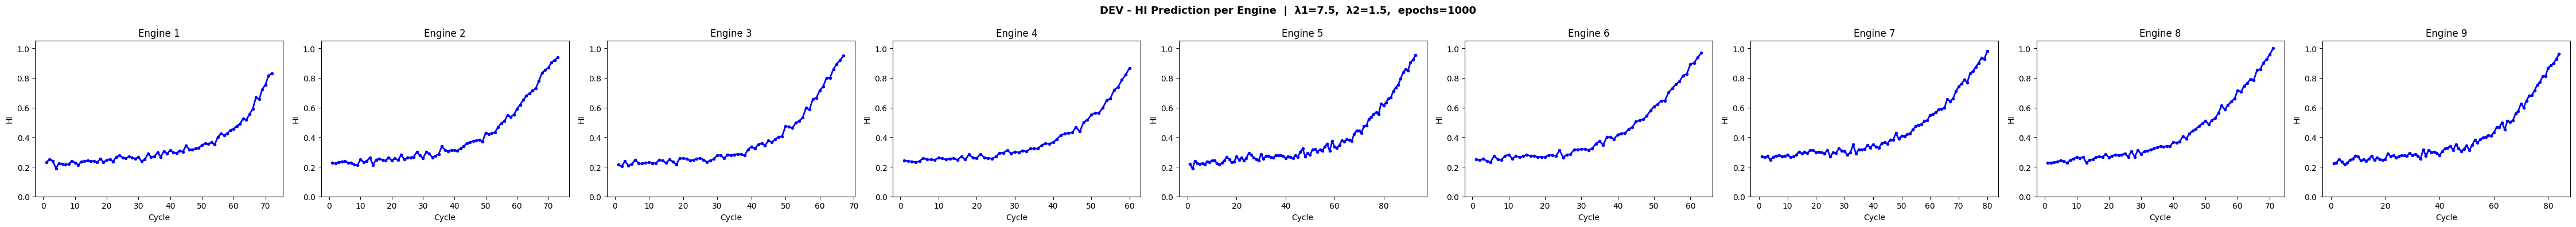

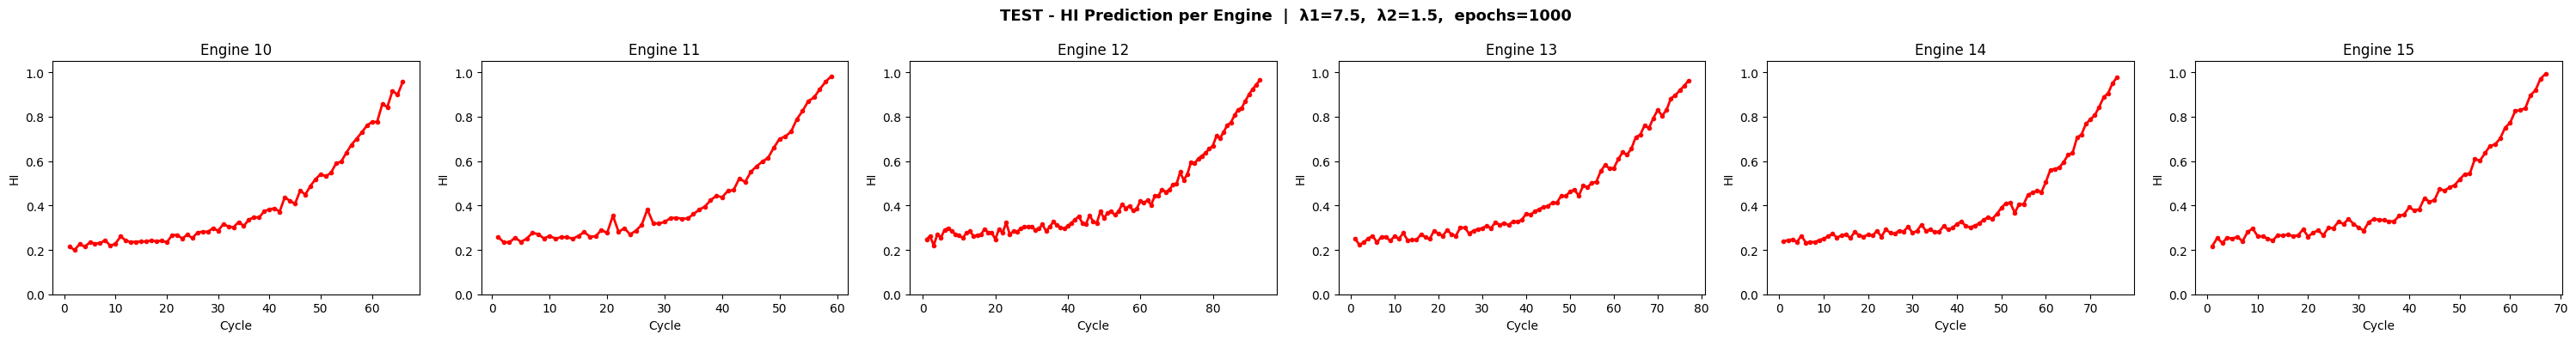


[15/16] lambda1=7.5, lambda2=2.0, epochs=1000
Final Loss: 0.609503


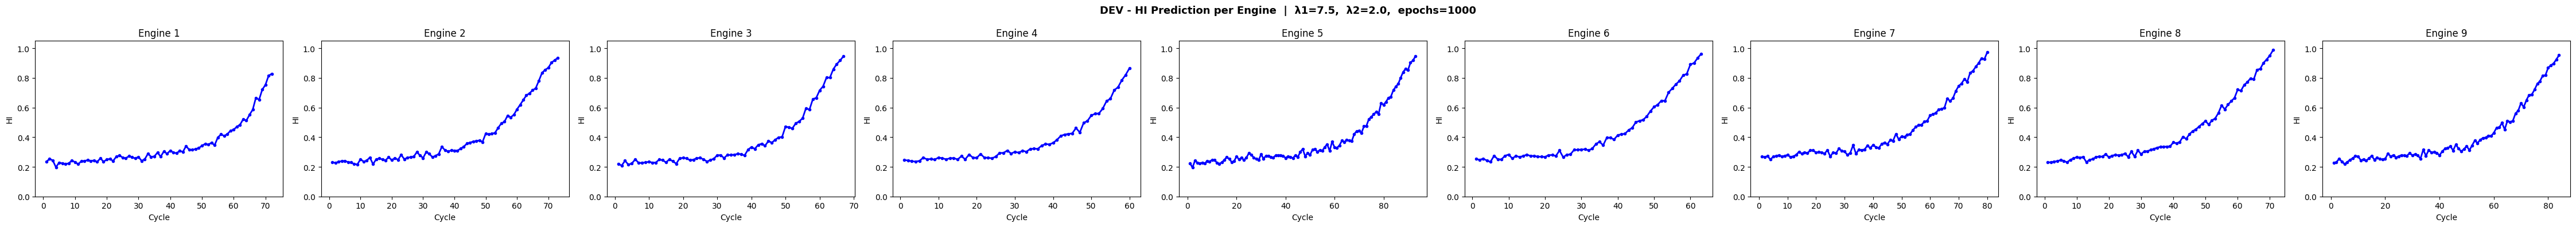

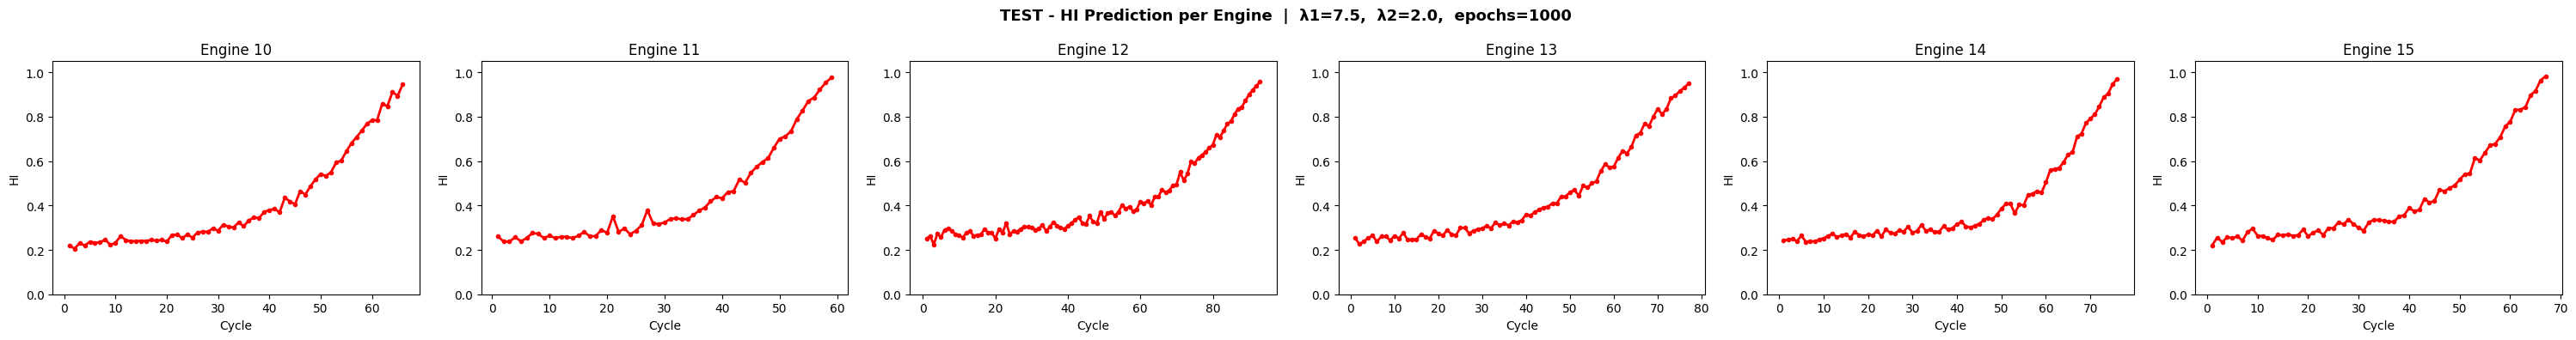


[16/16] lambda1=7.5, lambda2=2.5, epochs=1000
Final Loss: 0.683177


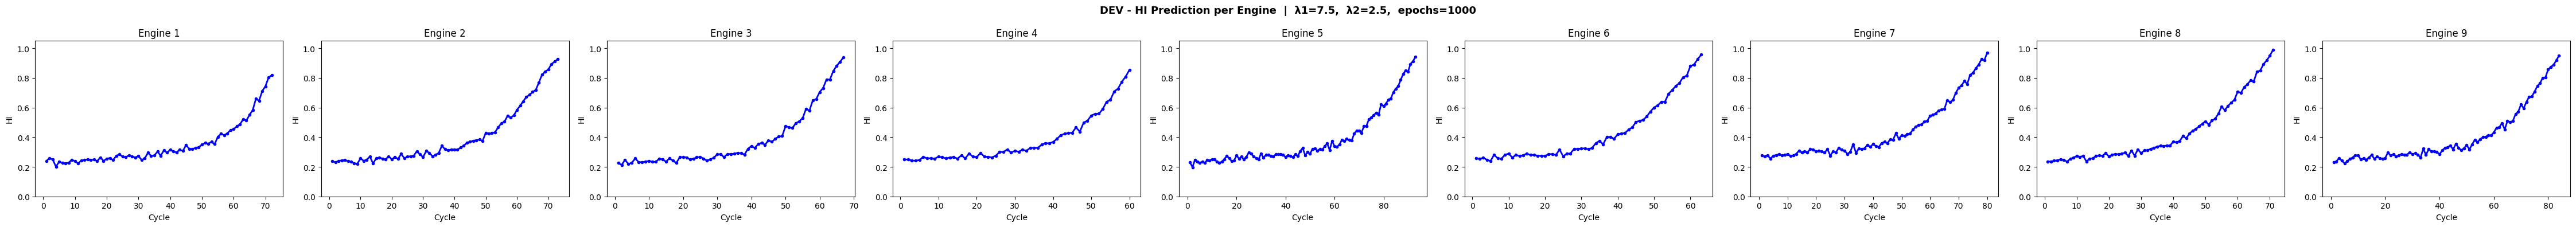

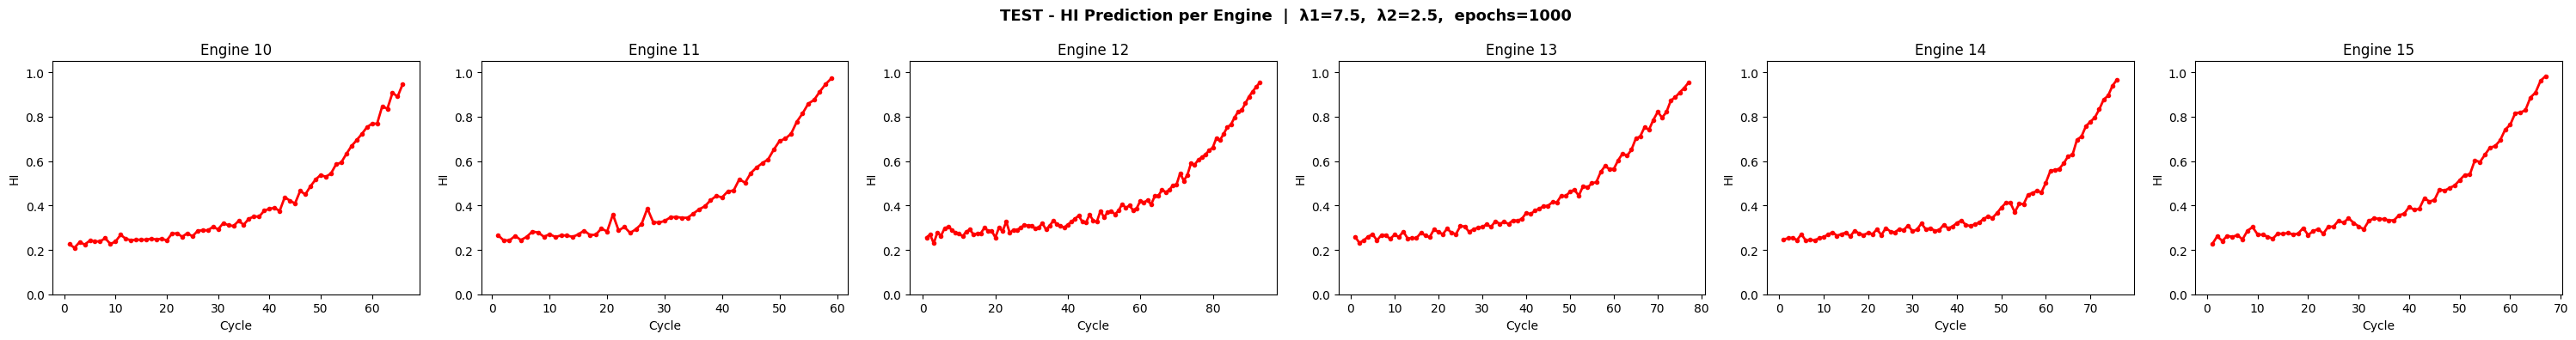



결과 요약 (final loss 낮은 순 top 5):
  lambda1=6.0, lambda2=1.0 -> final_loss=0.450506
  lambda1=6.5, lambda2=1.0 -> final_loss=0.455046
  lambda1=7.0, lambda2=1.0 -> final_loss=0.488101
  lambda1=6.0, lambda2=1.5 -> final_loss=0.493421
  lambda1=7.5, lambda2=1.0 -> final_loss=0.515309


In [23]:
from neural_fusion import train_model, predict
from visualisation import plot_HI_curves

lambda1_values = list(np.arange(6.0, 8.0, 0.5))   # 1.0, 1.5, 2.0, ..., 10.0
lambda2_values = list(np.arange(1.0, 3.0, 0.5))    # 0.0, 0.5, 1.0, ..., 5.0
epochs = [1000]

results = []
total = len(lambda1_values) * len(lambda2_values) * len(epochs)
count = 0

for l1 in lambda1_values:
    for l2 in lambda2_values:
        for ep in epochs:
            count += 1
            print(f"\n{'='*60}")
            print(f"[{count}/{total}] lambda1={l1}, lambda2={l2}, epochs={ep}")
            print(f"{'='*60}")
            model, loss_history = train_model(
                engine_data_list,
                epochs=int(ep),
                lambda0=1.0,
                lambda1=float(l1),
                lambda2=float(l2),
                init_threshold=0.2,  # 초기 HI 제약 활성화
                alpha=0.001,
                verbose=False,
                print_every=100
            )

            print(f"Final Loss: {loss_history[-1]:.6f}")

            plot_HI_curves(
                model=model,
                dev_normalized=dev_normalized,
                test_normalized=test_normalized,
                selected_sensors=selected_sensors,
                loss_history=loss_history,
                lambda1=l1,
                lambda2=l2,
                epochs=ep
)

            results.append({
                'lambda1':      l1,
                'lambda2':      l2,
                'final_loss':   loss_history[-1],
                'loss_history': loss_history,
                'model':        model,
        })

# 완료 후 loss 기준 상위 5개 출력
print("\n\n결과 요약 (final loss 낮은 순 top 5):")
sorted_results = sorted(results, key=lambda x: x['final_loss'])
for r in sorted_results[:5]:
    print(f"  lambda1={r['lambda1']}, lambda2={r['lambda2']} -> final_loss={r['final_loss']:.6f}")

In [30]:
from save_hi import save_HI_to_csv

dev_df, test_df = save_HI_to_csv(
    model=model,
    dev_normalized=dev_normalized,
    test_normalized=test_normalized,
    selected_sensors=selected_sensors,
    dev_path='dev_HI.csv',
    test_path='test_HI.csv'
)

DEV saved: dev_HI.csv (663 rows)
TEST saved: test_HI.csv (438 rows)
